In [1]:
from pathlib import Path
import os
import json
import re
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# -----------------------------
# Notebook-local utilities
# -----------------------------

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def _jsonable(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    return obj


def save_json(obj, path, indent=2):
    path = Path(path)
    ensure_dir(path.parent)
    path.write_text(json.dumps(_jsonable(obj), indent=indent, sort_keys=True))


# -----------------------------
# RASTA manifest scanning
# -----------------------------
LAYER_ALIASES = {
    'sup': ('sup', 'super', 'superficial', 'svc'),
    'deep': ('deep', 'dvc'),
    'cc': ('cc', 'choriocap', 'choriocapillaris'),
}
EYES = ('OD', 'OS')
IMAGE_EXTS = {'.bmp', '.png', '.jpg', '.jpeg', '.tif', '.tiff'}


def _normalise_name(name):
    return re.sub(r'[^a-z0-9]+', ' ', str(name).lower()).strip()


def infer_eye(filename):
    tokens = set(_normalise_name(filename).upper().split())
    for eye in EYES:
        if eye in tokens:
            return eye
    m = re.search(r'(?:^|[^A-Z])(OD|OS)(?:[^A-Z]|$)', str(filename).upper())
    return m.group(1) if m else None


def infer_layer(filename):
    norm = _normalise_name(filename)
    tokens = set(norm.split())
    for layer, aliases in LAYER_ALIASES.items():
        if any(alias in tokens or alias in norm for alias in aliases):
            return layer
    return None


def cohort_label_from_folder(folder_name):
    m = re.match(r'(\d+)[_\-\s]*(.*)', str(folder_name))
    if not m:
        return str(folder_name), None
    idx = int(m.group(1)) - 1
    name = m.group(2) or str(folder_name)
    return name, idx


def scan_image_manifest(root, require_all_layers=True):
    """Scan RASTA-style folders into one row per patient-eye.

    Expected structure: root/cohort_folder/patient_id/*.bmp.
    Naming is matched case-insensitively and tolerates spaces/underscores,
    e.g. `cc OD.bmp`, `Cc_OD.bmp`, `deep OS.bmp`.
    """
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f'Dataset root does not exist: {root}')

    records = []
    cohort_dirs = sorted([p for p in root.iterdir() if p.is_dir() and not p.name.startswith('.')], key=lambda p: p.name)
    label_map = {}

    for fallback_label, cohort_dir in enumerate(cohort_dirs):
        cohort_name, parsed_label = cohort_label_from_folder(cohort_dir.name)
        label = parsed_label if parsed_label is not None else fallback_label
        label_map[cohort_name] = label

        patient_dirs = sorted([p for p in cohort_dir.iterdir() if p.is_dir() and not p.name.startswith('.')], key=lambda p: p.name)
        for patient_dir in patient_dirs:
            per_eye = {eye: {'sup_path': None, 'deep_path': None, 'cc_path': None} for eye in EYES}
            for file in patient_dir.iterdir():
                if not file.is_file() or file.name.startswith('._') or file.suffix.lower() not in IMAGE_EXTS:
                    continue
                eye = infer_eye(file.name)
                layer = infer_layer(file.name)
                if eye is None or layer is None:
                    continue
                per_eye[eye][f'{layer}_path'] = str(file)

            for eye, paths in per_eye.items():
                has_any = any(paths.values())
                has_all = all(paths.values())
                if not has_any:
                    continue
                if require_all_layers and not has_all:
                    continue
                records.append({
                    'patient_id': patient_dir.name,
                    'cohort': cohort_name,
                    'cohort_folder': cohort_dir.name,
                    'label': label,
                    'eye': eye,
                    **paths,
                    'has_all_layers': has_all,
                })

    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values(['label', 'patient_id', 'eye']).reset_index(drop=True)
    df.attrs['label_map'] = label_map
    return df


# -----------------------------
# Clinical metadata helpers
# -----------------------------

def load_clinical_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if path.suffix.lower() in {'.xlsx', '.xls'}:
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df = df.rename(columns={c: str(c).strip() for c in df.columns})
    if 'ID' in df.columns and 'patient_id' not in df.columns:
        df = df.rename(columns={'ID': 'patient_id'})
    return df


def attach_clinical(manifest, clinical):
    if clinical is None or clinical.empty:
        return manifest.copy()
    if 'patient_id' not in clinical.columns:
        raise ValueError('Clinical table must contain ID or patient_id column')
    return manifest.merge(clinical, on='patient_id', how='left', validate='many_to_one')


def default_clinical_columns(df):
    preferred = [
        'Age', 'Sex', 'Congestive heart failure', 'Hypertension',
        'Diabetes mellitus', 'Stroke', 'Vascular disease', 'Body mass index',
        'CHA2DS2-VASc', 'Obstructive sleep apnea syndrom', 'Smoking', 'Dyslipidemia',
    ]
    stripped = {str(c).strip(): c for c in df.columns}
    cols = [stripped[c] for c in preferred if c in stripped]
    if cols:
        return cols
    exclude = {
        'patient_id', 'cohort', 'cohort_folder', 'label', 'eye',
        'sup_path', 'deep_path', 'cc_path', 'fold', 'has_all_layers'
    }
    return [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]


def make_age_decade(age):
    age = pd.to_numeric(age, errors='coerce')
    decade = (age.fillna(-1) // 10).astype(int) * 10
    return decade.astype(str).where(age.notna(), 'age_missing')


def dataset_audit(df, clinical_cols=None):
    audit = {}
    audit['n_eye_samples'] = int(len(df))
    audit['n_patients'] = int(df['patient_id'].nunique()) if 'patient_id' in df else 0

    if 'cohort' in df:
        audit['class_counts_eye'] = df['cohort'].value_counts().to_dict()
        patient_counts = df.drop_duplicates('patient_id')['cohort'].value_counts().to_dict()
        audit['class_counts_patient'] = patient_counts
        counts = np.array(list(patient_counts.values()), dtype=float)
        audit['class_imbalance_ratio_patient'] = float(counts.max() / max(counts.min(), 1)) if len(counts) else np.nan

    if {'patient_id', 'eye'}.issubset(df.columns):
        eyes_per_patient = df.groupby('patient_id')['eye'].agg(lambda x: '+'.join(sorted(set(x))))
        audit['bilateral_availability'] = eyes_per_patient.value_counts().to_dict()

    layer_cols = [c for c in ['sup_path', 'deep_path', 'cc_path'] if c in df]
    audit['layer_missing_counts'] = {c: int(df[c].isna().sum()) for c in layer_cols}

    if clinical_cols:
        missing = df[list(clinical_cols)].isna().sum().sort_values(ascending=False)
        audit['clinical_missing_counts'] = missing.astype(int).to_dict()
        if 'cohort' in df:
            by_cohort = {}
            for cohort, group in df.groupby('cohort'):
                by_cohort[cohort] = group[list(clinical_cols)].isna().sum().astype(int).to_dict()
            audit['clinical_missing_by_cohort'] = by_cohort

    if 'patient_id' in df and 'cohort' in df:
        leakage = df.groupby('patient_id')['cohort'].nunique()
        audit['patients_in_multiple_cohorts'] = leakage[leakage > 1].index.tolist()

    return audit


# -----------------------------
# Patient-level fold helpers
# -----------------------------

def make_stratification_key(df, age_col='Age', sex_col='Sex'):
    label = df['label'].astype(str)
    key = label.copy()
    if age_col and age_col in df.columns:
        key = key + '_' + make_age_decade(df[age_col])
    if sex_col and sex_col in df.columns:
        sex = df[sex_col].astype('object').where(df[sex_col].notna(), 'sex_missing').astype(str)
        key = key + '_' + sex
    counts = key.value_counts()
    rare = key.map(counts) < 2
    return key.where(~rare, label)


def assign_patient_folds(df, n_splits=5, seed=42, age_col='Age', sex_col='Sex'):
    if not {'patient_id', 'label'}.issubset(df.columns):
        raise ValueError('df must include patient_id and label columns')

    out = df.copy().reset_index(drop=True)
    patient_df = out.drop_duplicates('patient_id').reset_index(drop=True)
    y = make_stratification_key(patient_df, age_col=age_col, sex_col=sex_col)
    groups = patient_df['patient_id'].astype(str)
    folds = np.full(len(patient_df), -1, dtype=int)

    try:
        from sklearn.model_selection import StratifiedGroupKFold
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for fold, (_, val_idx) in enumerate(splitter.split(patient_df, y, groups)):
            folds[val_idx] = fold
    except Exception:
        # Deterministic label/stratum-balanced fallback at patient level.
        rng = np.random.default_rng(seed)
        fold_sizes = np.zeros(n_splits, dtype=int)
        for _, grp in patient_df.assign(_key=y.values).groupby('_key', sort=False):
            idx = grp.index.to_numpy()
            rng.shuffle(idx)
            for i in idx:
                f = int(np.argmin(fold_sizes))
                folds[i] = f
                fold_sizes[f] += 1

    patient_to_fold = dict(zip(patient_df['patient_id'], folds.astype(int)))
    out['fold'] = out['patient_id'].map(patient_to_fold).astype(int)
    validate_patient_folds(out, n_splits=n_splits)
    return out


def validate_patient_folds(df, n_splits=None):
    per_patient = df.groupby('patient_id')['fold'].nunique()
    bad = per_patient[per_patient > 1]
    if len(bad):
        raise AssertionError(f'Patient leakage across folds: {bad.index.tolist()[:10]}')
    if n_splits is not None:
        got = set(df['fold'].dropna().astype(int).unique())
        expected = set(range(n_splits))
        if not got.issubset(expected):
            raise AssertionError(f'Unexpected fold ids: {got - expected}')


seed_everything(42)
sns.set_theme(style='whitegrid', context='notebook')
PROJECT_ROOT = Path.cwd()

In [2]:
# ============================================================
# EDIT THESE PATHS ON THE WINDOWS MACHINE
# ============================================================

# 1) RASTA image dataset folder. Example Windows path:
# DATA_ROOT_STR = r"D:\RASTA\Rasta dataset"
DATA_ROOT_STR = r"J:\Rasta dataset"

# 2) Clinical spreadsheet path. If it is in the same folder as this notebook,
#    the default below should work. Example Windows path:
# CLINICAL_PATH_STR = r"D:\RASTA\table_for_publication .xlsx"
CLINICAL_PATH_STR = r"J:\Rasta dataset\table_for_publication.xlsx"

# 3) Output folder for Phase 1 reports/plots. Relative paths are saved beside the notebook.
OUTPUT_DIR_STR = r"outputs/phase1_dataset_analysis"

# Optional runtime settings
REQUIRE_ALL_LAYERS_FOR_MODEL = True
QC_MAX_IMAGES_PER_LAYER = None  # set e.g. 500 for a quicker smoke-test audit


def choose_path(user_value, env_name, default_value):
    """Choose path in order: explicit notebook value -> environment variable -> default."""
    value = str(user_value).strip() if user_value is not None else ""
    if not value:
        value = os.environ.get(env_name, default_value)
    return Path(value).expanduser()


DATA_ROOT = choose_path(DATA_ROOT_STR, 'RASTA_DATA_ROOT', 'Rasta dataset')
CLINICAL_PATH = choose_path(CLINICAL_PATH_STR, 'RASTA_CLINICAL_PATH', 'table_for_publication .xlsx')
OUTPUT_DIR = ensure_dir(Path(OUTPUT_DIR_STR).expanduser())

print('DATA_ROOT      =', DATA_ROOT.resolve() if DATA_ROOT.exists() else DATA_ROOT)
print('CLINICAL_PATH  =', CLINICAL_PATH.resolve() if CLINICAL_PATH.exists() else CLINICAL_PATH)
print('OUTPUT_DIR     =', OUTPUT_DIR.resolve())
print()
print('To change paths on Windows, edit DATA_ROOT_STR and CLINICAL_PATH_STR in this cell only.')

DATA_ROOT      = J:\Rasta dataset
CLINICAL_PATH  = J:\Rasta dataset\table_for_publication.xlsx
OUTPUT_DIR     = C:\Users\BIOMIL\retina-project\outputs\phase1_dataset_analysis

To change paths on Windows, edit DATA_ROOT_STR and CLINICAL_PATH_STR in this cell only.


In [9]:
clinical_df = load_clinical_table(CLINICAL_PATH)
print('Clinical shape:', clinical_df.shape)
display(clinical_df.head())
print('Columns:')
print(list(clinical_df.columns))

Clinical shape: (491, 43)


,patient_id,Age,Sex,Congestive heart failure,Hypertension,Diabetes mellitus,Stroke,Vascular disease,Body mass index,CHA2DS2-VASc,...,DENS_Circle6mm_deep_OD,DENS_Average_FOV_deep_OS,DENS_Circle3mm_deep_OS,DENS_Circle6mm_deep_OS,PERF_Average_FOV_deep_OD,PERF_Circle3mm_deep_OD,PERF_Circle6mm_deep_OD,PERF_Average_FOV_deep_OS,PERF_Circle3mm_deep_OS,PERF_Circle6mm_deep_OS
0,1ALVA91,29.616438,1,0,0,0,0,0,24.675500,1,...,1.041500,NaN,NaN,NaN,0.020275,0.022143,0.019705,NaN,NaN,NaN
1,1ANSA78,42.863014,1,0,0,0,0,0,21.107266,1,...,14.235421,16.256510,18.797400,16.478782,0.283279,0.425048,0.295482,0.344589,0.430852,0.351890
2,1ARLO88,33.345205,0,0,0,0,0,0,24.515595,0,...,4.819097,NaN,NaN,NaN,0.094086,0.110395,0.097466,NaN,NaN,NaN
3,1BACH95,26.112329,1,0,0,0,0,0,NaN,1,...,13.009584,13.672201,12.689816,13.854343,0.250130,0.228396,0.256283,0.275177,0.253561,0.276135
4,1BAEL95,25.704110,1,0,0,0,0,0,19.531250,1,...,14.280721,15.148437,13.455881,14.841489,0.280792,0.249112,0.278857,0.306355,0.266288,0.295884


Columns:
['patient_id', 'Age', 'Sex', 'Congestive heart failure', 'Hypertension', 'Diabetes mellitus', 'Stroke', 'Vascular disease', 'Body mass index', 'CHA2DS2-VASc', 'Obstructive sleep apnea syndrom', 'Smoking', 'Dyslipidemia', 'FAZRawLength_OD', 'FazCircularity_OD', 'FAZRawSize_OD', 'FAZRawLength_OS', 'FazCircularity_OS', 'FAZRawSize_OS', 'DENS_Average_FOV_sup_OD', 'DENS_Circle3mm_sup_OD', 'DENS_Circle6mm_sup_OD', 'DENS_Average_FOV_sup_OS', 'DENS_Circle3mm_sup_OS', 'DENS_Circle6mm_sup_OS', 'PERF_Average_FOV_sup_OD', 'PERF_Circle3mm_sup_OD', 'PERF_Circle6mm_sup_OD', 'PERF_Average_FOV_sup_OS', 'PERF_Circle3mm_sup_OS', 'PERF_Circle6mm_sup_OS', 'DENS_Average_FOV_deep_OD', 'DENS_Circle3mm_deep_OD', 'DENS_Circle6mm_deep_OD', 'DENS_Average_FOV_deep_OS', 'DENS_Circle3mm_deep_OS', 'DENS_Circle6mm_deep_OS', 'PERF_Average_FOV_deep_OD', 'PERF_Circle3mm_deep_OD', 'PERF_Circle6mm_deep_OD', 'PERF_Average_FOV_deep_OS', 'PERF_Circle3mm_deep_OS', 'PERF_Circle6mm_deep_OS']


In [12]:
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f'DATA_ROOT does not exist: {DATA_ROOT}\n\n'
        'Edit DATA_ROOT_STR in the Configuration cell above. '
        'For Windows, use a raw string like: r"D:\\RASTA\\Rasta dataset"'
    )

manifest_all = scan_image_manifest(DATA_ROOT, require_all_layers=False)
manifest = scan_image_manifest(DATA_ROOT, require_all_layers=REQUIRE_ALL_LAYERS_FOR_MODEL)
manifest_clin = attach_clinical(manifest, clinical_df)

manifest_all.to_csv(OUTPUT_DIR / 'manifest_all_detected_eyes.csv', index=False)
manifest_clin.to_csv(OUTPUT_DIR / 'manifest_model_ready_with_clinical.csv', index=False)

print('All detected eye rows:', manifest_all.shape)
print('Model-ready rows with all layers:', manifest.shape)
display(manifest_clin.head())

All detected eye rows: (476, 9)
Model-ready rows with all layers: (476, 9)


,patient_id,cohort,cohort_folder,label,eye,sup_path,deep_path,cc_path,has_all_layers,Age,...,DENS_Circle6mm_deep_OD,DENS_Average_FOV_deep_OS,DENS_Circle3mm_deep_OS,DENS_Circle6mm_deep_OS,PERF_Average_FOV_deep_OD,PERF_Circle3mm_deep_OD,PERF_Circle6mm_deep_OD,PERF_Average_FOV_deep_OS,PERF_Circle3mm_deep_OS,PERF_Circle6mm_deep_OS
0,1ALVA91,RETINORM,1_RETINORM,0,OD,J:\Rasta dataset\1_RETINORM\1ALVA91\sup OD.bmp,J:\Rasta dataset\1_RETINORM\1ALVA91\deep OD.bmp,J:\Rasta dataset\1_RETINORM\1ALVA91\cc OD.bmp,True,29.616438,...,1.041500,NaN,NaN,NaN,0.020275,0.022143,0.019705,NaN,NaN,NaN
1,1ANSA78,RETINORM,1_RETINORM,0,OD,J:\Rasta dataset\1_RETINORM\1ANSA78\sup OD.bmp,J:\Rasta dataset\1_RETINORM\1ANSA78\deep OD.bmp,J:\Rasta dataset\1_RETINORM\1ANSA78\cc OD.bmp,True,42.863014,...,14.235421,16.25651,18.7974,16.478782,0.283279,0.425048,0.295482,0.344589,0.430852,0.35189
2,1ANSA78,RETINORM,1_RETINORM,0,OS,J:\Rasta dataset\1_RETINORM\1ANSA78\sup OS.bmp,J:\Rasta dataset\1_RETINORM\1ANSA78\deep OS.bmp,J:\Rasta dataset\1_RETINORM\1ANSA78\cc OS.bmp,True,42.863014,...,14.235421,16.25651,18.7974,16.478782,0.283279,0.425048,0.295482,0.344589,0.430852,0.35189
3,1ARLO88,RETINORM,1_RETINORM,0,OD,J:\Rasta dataset\1_RETINORM\1ARLO88\sup OD.bmp,J:\Rasta dataset\1_RETINORM\1ARLO88\deep OD.bmp,J:\Rasta dataset\1_RETINORM\1ARLO88\cc OD.bmp,True,33.345205,...,4.819097,NaN,NaN,NaN,0.094086,0.110395,0.097466,NaN,NaN,NaN
4,1ARLO88,RETINORM,1_RETINORM,0,OS,J:\Rasta dataset\1_RETINORM\1ARLO88\sup OS.bmp,J:\Rasta dataset\1_RETINORM\1ARLO88\deep OS.bmp,J:\Rasta dataset\1_RETINORM\1ARLO88\cc OS.bmp,True,33.345205,...,4.819097,NaN,NaN,NaN,0.094086,0.110395,0.097466,NaN,NaN,NaN


In [11]:
clinical_cols = default_clinical_columns(manifest_clin)
audit = dataset_audit(manifest_clin, clinical_cols=clinical_cols)
save_json(audit, OUTPUT_DIR / 'dataset_audit.json')

print(json.dumps(audit, indent=2, default=str))

class_eye = manifest_clin['cohort'].value_counts().rename_axis('cohort').reset_index(name='eye_count')
class_patient = manifest_clin.drop_duplicates('patient_id')['cohort'].value_counts().rename_axis('cohort').reset_index(name='patient_count')
class_table = class_patient.merge(class_eye, on='cohort', how='outer')
class_table.to_csv(OUTPUT_DIR / 'class_distribution.csv', index=False)
display(class_table)

{
  "n_eye_samples": 476,
  "n_patients": 265,
  "class_counts_eye": {
    "FAMILIPO": 156,
    "ORNET": 150,
    "RETINORM": 136,
    "MRCC": 34
  },
  "class_counts_patient": {
    "FAMILIPO": 81,
    "ORNET": 77,
    "RETINORM": 75,
    "MRCC": 32
  },
  "class_imbalance_ratio_patient": 2.53125,
  "bilateral_availability": {
    "OD+OS": 211,
    "OD": 35,
    "OS": 19
  },
  "layer_missing_counts": {
    "sup_path": 0,
    "deep_path": 0,
    "cc_path": 0
  },
  "clinical_missing_counts": {
    "Body mass index": 44,
    "Dyslipidemia": 2,
    "Age": 0,
    "Sex": 0,
    "Hypertension": 0,
    "Congestive heart failure": 0,
    "Stroke": 0,
    "Diabetes mellitus": 0,
    "Vascular disease": 0,
    "CHA2DS2-VASc": 0,
    "Obstructive sleep apnea syndrom": 0,
    "Smoking": 0
  },
  "clinical_missing_by_cohort": {
    "FAMILIPO": {
      "Age": 0,
      "Sex": 0,
      "Congestive heart failure": 0,
      "Hypertension": 0,
      "Diabetes mellitus": 0,
      "Stroke": 0,
      "Vas

,cohort,patient_count,eye_count
0,FAMILIPO,81,156
1,MRCC,32,34
2,ORNET,77,150
3,RETINORM,75,136


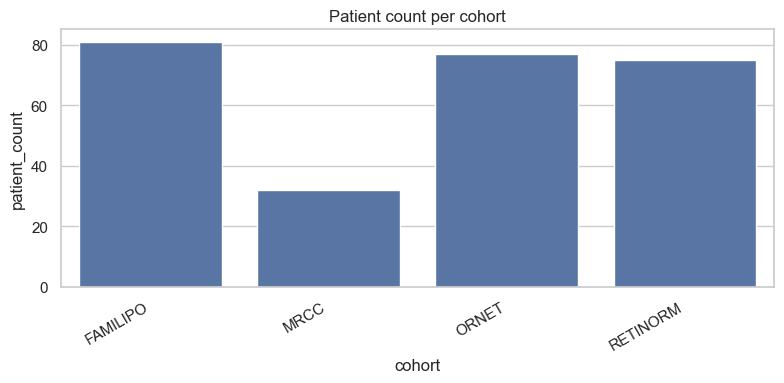

,eye_availability,patient_count
0,OD+OS,211
1,OD,35
2,OS,19


In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(data=class_table, x='cohort', y='patient_count', color='#4C72B0')
plt.xticks(rotation=30, ha='right')
plt.title('Patient count per cohort')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution_patients.png', dpi=200)
plt.show()

eyes_per_patient = manifest_clin.groupby('patient_id')['eye'].agg(lambda s: '+'.join(sorted(set(s))))
bilat = eyes_per_patient.value_counts().rename_axis('eye_availability').reset_index(name='patient_count')
bilat.to_csv(OUTPUT_DIR / 'bilateral_availability.csv', index=False)
display(bilat)

,missing_fraction
Body mass index,0.092437
Dyslipidemia,0.004202
Age,0.000000
Sex,0.000000
Hypertension,0.000000
Congestive heart failure,0.000000
Stroke,0.000000
Diabetes mellitus,0.000000
Vascular disease,0.000000
CHA2DS2-VASc,0.000000


,cohort,Age,Sex,Congestive heart failure,Hypertension,Diabetes mellitus,Stroke,Vascular disease,Body mass index,CHA2DS2-VASc,Obstructive sleep apnea syndrom,Smoking,Dyslipidemia
0,FAMILIPO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.038462,0.0,0.0,0.0,0.000000
1,MRCC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
2,ORNET,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
3,RETINORM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.279412,0.0,0.0,0.0,0.014706


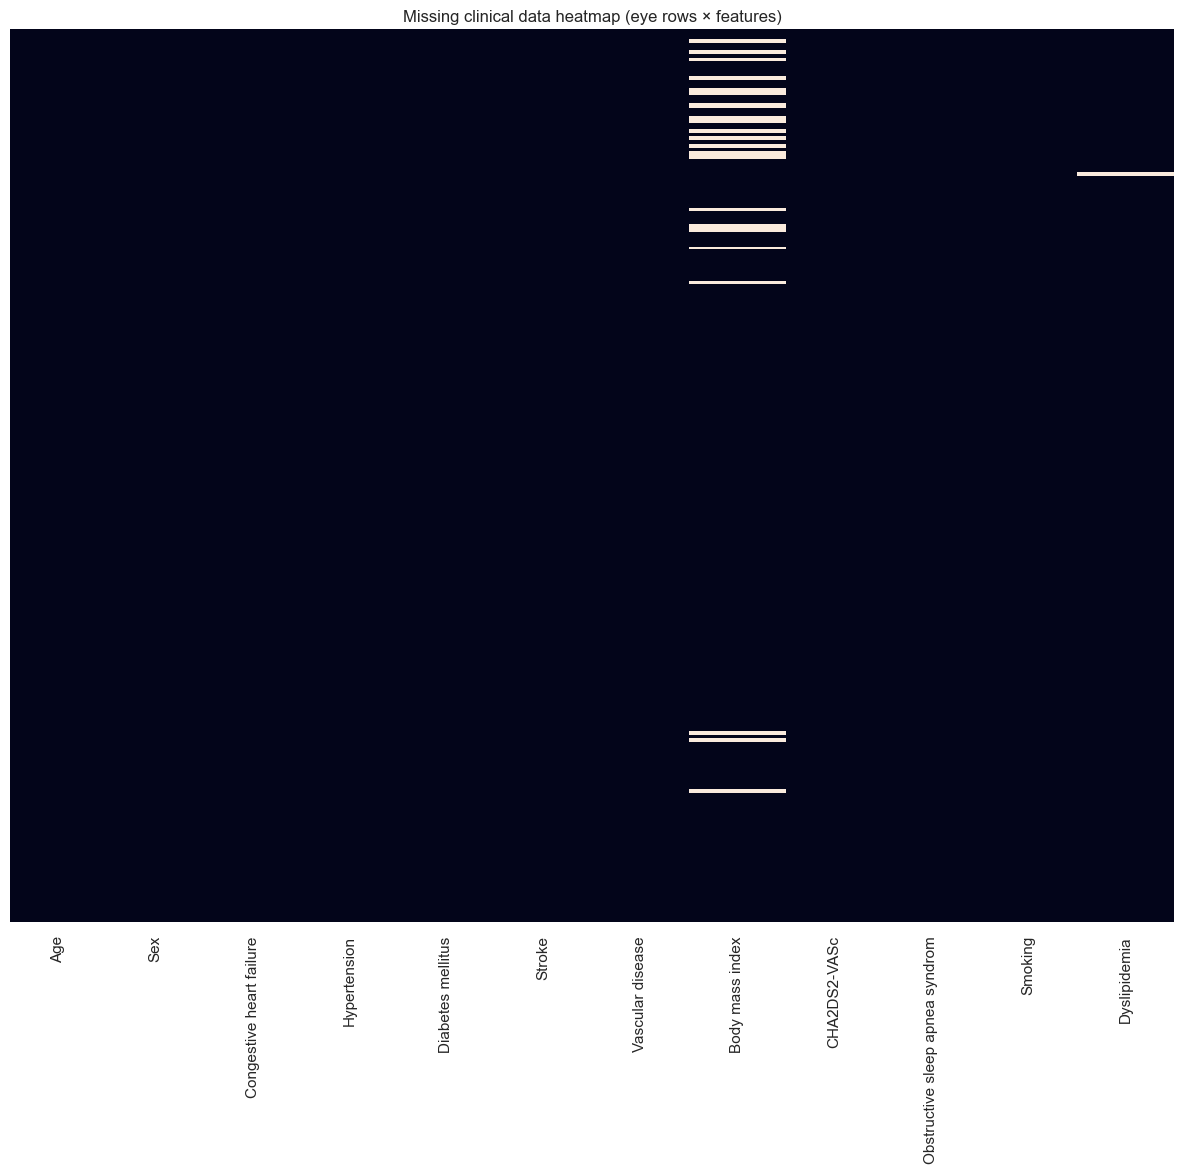

In [7]:
missing_overall = manifest_clin[clinical_cols].isna().mean().sort_values(ascending=False).rename('missing_fraction')
missing_by_cohort = manifest_clin.groupby('cohort')[clinical_cols].apply(lambda g: g.isna().mean()).reset_index()
missing_overall.to_csv(OUTPUT_DIR / 'clinical_missing_overall.csv')
missing_by_cohort.to_csv(OUTPUT_DIR / 'clinical_missing_by_cohort.csv', index=False)
display(missing_overall.to_frame())
display(missing_by_cohort)

plt.figure(figsize=(12, max(4, 0.025 * len(manifest_clin))))
sns.heatmap(manifest_clin[clinical_cols].isna(), cbar=False, yticklabels=False)
plt.title('Missing clinical data heatmap (eye rows × features)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clinical_missingness_heatmap.png', dpi=200)
plt.show()

Age                                                          Sex  \
         count       mean        std     median        min        max count   
cohort                                                                        
FAMILIPO    81  52.835447  18.694738  57.306849  11.547945  79.002740    81   
MRCC        32  69.576541   7.014793  69.554795  49.632877  82.339726    32   
ORNET       77  54.350009  12.931747  55.726027  18.769863  81.964384    77   
RETINORM    75  50.361680  20.026573  54.761644  18.263014  86.939726    75   

                                            Body mass index             \
              mean       std median min max           count       mean   
cohort                                                                   
FAMILIPO  0.469136  0.502156    0.0   0   1              78  26.338003   
MRCC      0.156250  0.368902    0.0   0   1              32  27.474799   
ORNET     0.545455  0.501195    1.0   0   1              77  30.614036   
RETINORM  0.640000  0.483232    1.0   0   1              54  25.069812   

                                                     
               std     median        min        max  
cohort                                               
FAMILIPO  5.010061  25.954077  16.514731  41.623309  
MRCC      3.358708  26.467687  22.491349  35.031027  
ORNET     7.862048  29.065744  18.359375  59.369913  
RETINORM  4.592643  24.262263  18.717546  38.014227

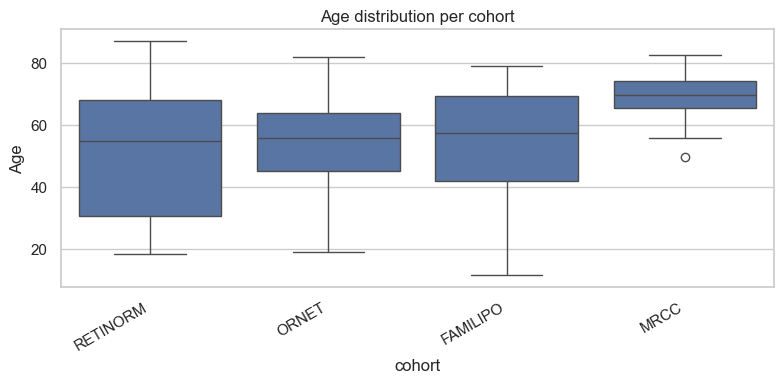

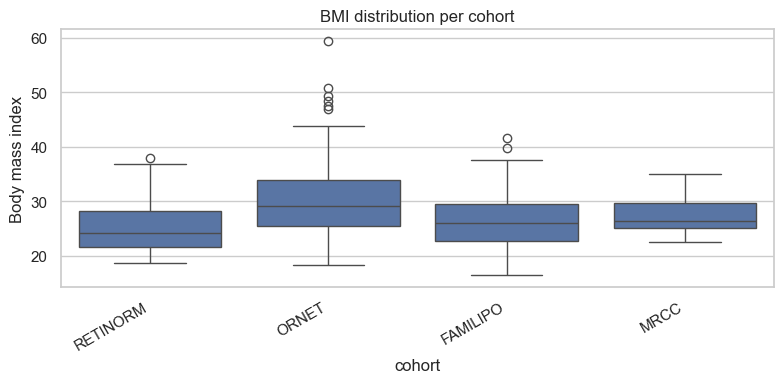

In [8]:
demo_cols = [c for c in ['Age', 'Sex', 'Body mass index'] if c in manifest_clin.columns]
demo_summary = manifest_clin.drop_duplicates('patient_id').groupby('cohort')[demo_cols].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
demo_summary.to_csv(OUTPUT_DIR / 'demographic_summary_by_cohort.csv')
display(demo_summary)

if 'Age' in manifest_clin.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=manifest_clin.drop_duplicates('patient_id'), x='cohort', y='Age')
    plt.xticks(rotation=30, ha='right')
    plt.title('Age distribution per cohort')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'age_distribution_by_cohort.png', dpi=200)
    plt.show()

if 'Body mass index' in manifest_clin.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=manifest_clin.drop_duplicates('patient_id'), x='cohort', y='Body mass index')
    plt.xticks(rotation=30, ha='right')
    plt.title('BMI distribution per cohort')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'bmi_distribution_by_cohort.png', dpi=200)
    plt.show()

,layer,path,height,width,mean,std,min,max,zero_variance,readable
0,sup,J:\Rasta dataset\1_RETINORM\1ALVA91\sup OD.bmp,1024,1024,110.314758,58.769955,0.0,255.0,False,True
1,sup,J:\Rasta dataset\1_RETINORM\1ANSA78\sup OD.bmp,1024,1024,118.804565,70.248001,0.0,255.0,False,True
2,sup,J:\Rasta dataset\1_RETINORM\1ANSA78\sup OS.bmp,1024,1024,121.418739,69.838455,0.0,255.0,False,True
3,sup,J:\Rasta dataset\1_RETINORM\1ARLO88\sup OD.bmp,1024,1024,92.390205,60.057354,0.0,255.0,False,True
4,sup,J:\Rasta dataset\1_RETINORM\1ARLO88\sup OS.bmp,1024,1024,87.222916,56.683960,0.0,255.0,False,True


,layer,n,readable,zero_variance,median_height,median_width,median_std
0,cc,476,476,0,1024.0,1024.0,47.004934
1,deep,476,476,0,1024.0,1024.0,46.772285
2,sup,476,476,0,1024.0,1024.0,68.021564


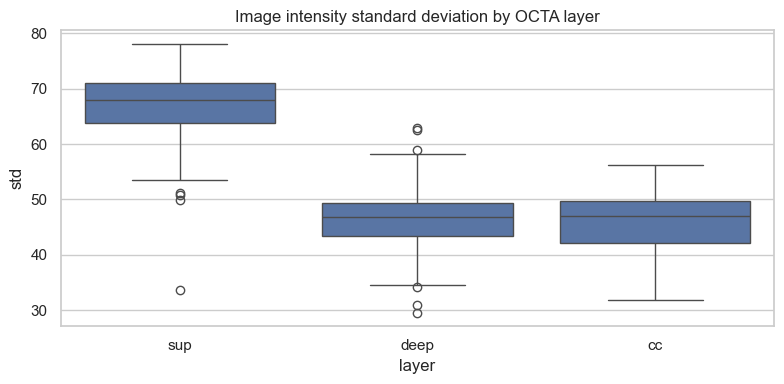

In [9]:
def audit_image_paths(df, max_per_layer=None):
    rows = []
    for layer, col in [('sup', 'sup_path'), ('deep', 'deep_path'), ('cc', 'cc_path')]:
        paths = df[col].dropna().tolist()
        if max_per_layer is not None:
            paths = paths[:max_per_layer]
        for p in paths:
            rec = {'layer': layer, 'path': p}
            try:
                with Image.open(p) as img:
                    arr = np.asarray(img.convert('L'), dtype=np.float32)
                rec.update({
                    'height': int(arr.shape[0]), 'width': int(arr.shape[1]),
                    'mean': float(arr.mean()), 'std': float(arr.std()),
                    'min': float(arr.min()), 'max': float(arr.max()),
                    'zero_variance': bool(arr.std() <= 1e-6),
                    'readable': True,
                })
            except Exception as e:
                rec.update({'readable': False, 'error': repr(e)})
            rows.append(rec)
    return pd.DataFrame(rows)

image_qc = audit_image_paths(manifest_clin, max_per_layer=QC_MAX_IMAGES_PER_LAYER)
image_qc.to_csv(OUTPUT_DIR / 'image_quality_audit.csv', index=False)
display(image_qc.head())

qc_summary = image_qc.groupby('layer').agg(
    n=('path', 'count'),
    readable=('readable', 'sum'),
    zero_variance=('zero_variance', 'sum'),
    median_height=('height', 'median'),
    median_width=('width', 'median'),
    median_std=('std', 'median'),
).reset_index()
qc_summary.to_csv(OUTPUT_DIR / 'image_quality_summary.csv', index=False)
display(qc_summary)

if not image_qc.empty and 'std' in image_qc:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=image_qc[image_qc['readable']], x='layer', y='std')
    plt.title('Image intensity standard deviation by OCTA layer')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'image_std_by_layer.png', dpi=200)
    plt.show()

Detected biomarker columns: 30
['FAZRawLength_OD', 'FazCircularity_OD', 'FAZRawSize_OD', 'FAZRawLength_OS', 'FazCircularity_OS', 'FAZRawSize_OS', 'DENS_Average_FOV_sup_OD', 'DENS_Circle3mm_sup_OD', 'DENS_Circle6mm_sup_OD', 'DENS_Average_FOV_sup_OS', 'DENS_Circle3mm_sup_OS', 'DENS_Circle6mm_sup_OS', 'PERF_Average_FOV_sup_OD', 'PERF_Circle3mm_sup_OD', 'PERF_Circle6mm_sup_OD', 'PERF_Average_FOV_sup_OS', 'PERF_Circle3mm_sup_OS', 'PERF_Circle6mm_sup_OS', 'DENS_Average_FOV_deep_OD', 'DENS_Circle3mm_deep_OD']


FAZRawLength_OD                               FazCircularity_OD  \
                   count      mean       std    median             count   
cohort                                                                     
FAMILIPO             156  2.258471  1.363270  1.998851               156   
MRCC                  29  3.270712  6.011313  2.201056                29   
ORNET                148  2.228918  1.139902  2.053078               148   
RETINORM             129  2.216218  0.987182  2.112505               129   

                                       FAZRawSize_OD                      \
              mean       std    median         count      mean       std   
cohort                                                                     
FAMILIPO  0.668834  0.150654  0.701406           156  0.290784  0.283998   
MRCC      0.688620  0.145889  0.745036            29  0.523020  1.377850   
ORNET     0.708525  0.114310  0.737077           148  0.291242  0.254242   
RETINORM  0.713647  0.100647  0.718138           129  0.293947  0.224520   

                   FAZRawLength_OS                                
            median           count      mean       std    median  
cohort                                                            
FAMILIPO  0.220550             156  2.560992  3.355722  1.948198  
MRCC      0.287224               4  4.868124  4.812565  2.829259  
ORNET     0.248566             150  2.434992  1.716723  2.071073  
RETINORM  0.244514             128  3.312555  9.176981  2.193703

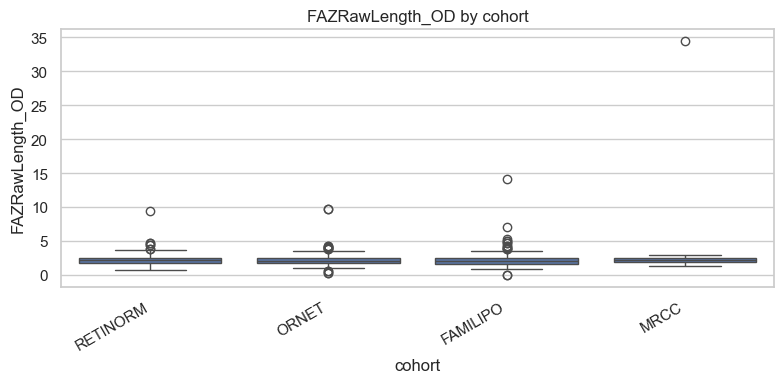

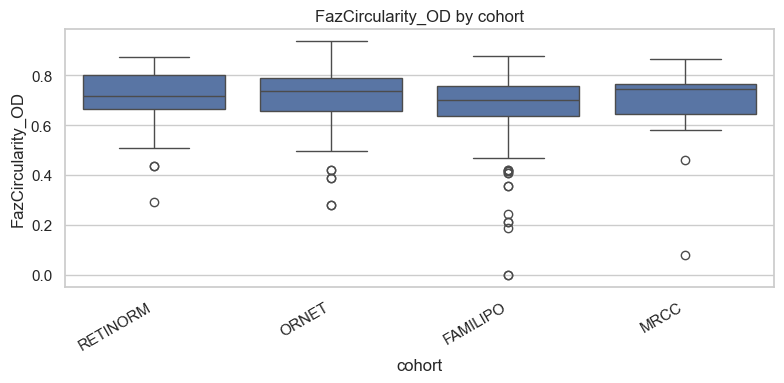

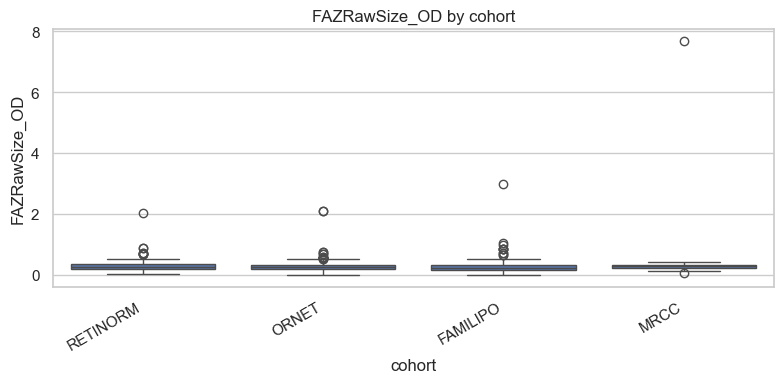

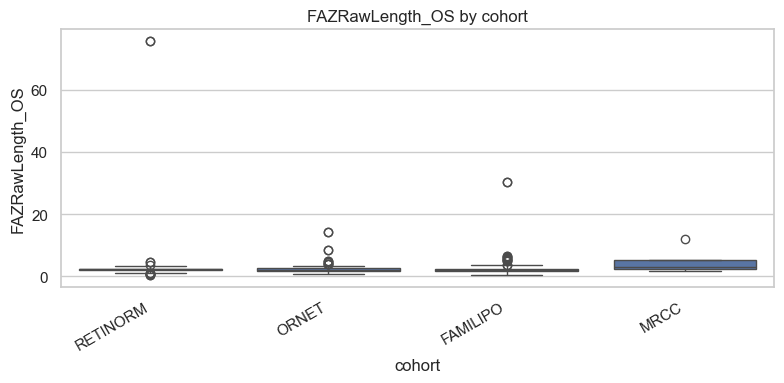

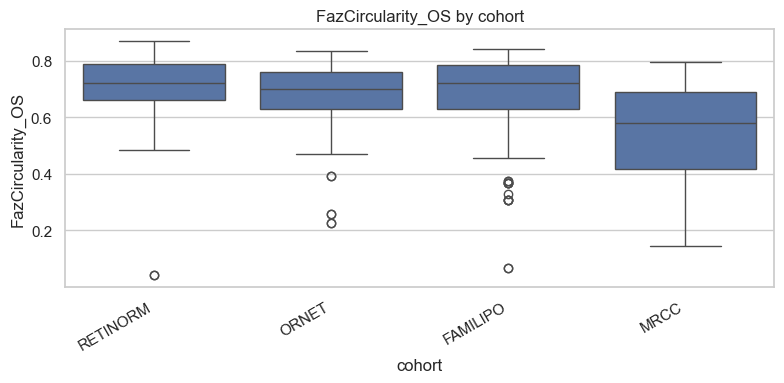

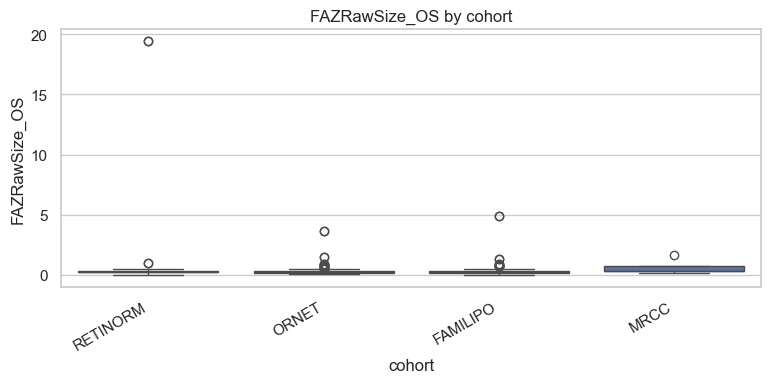

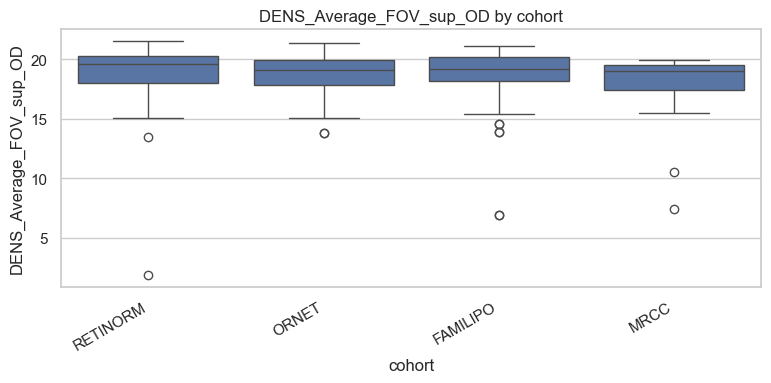

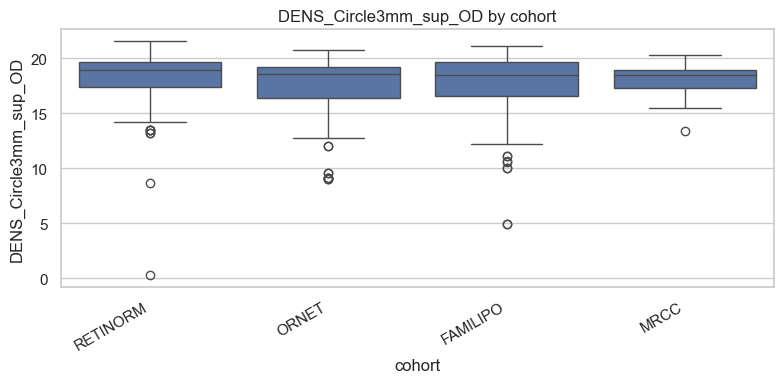

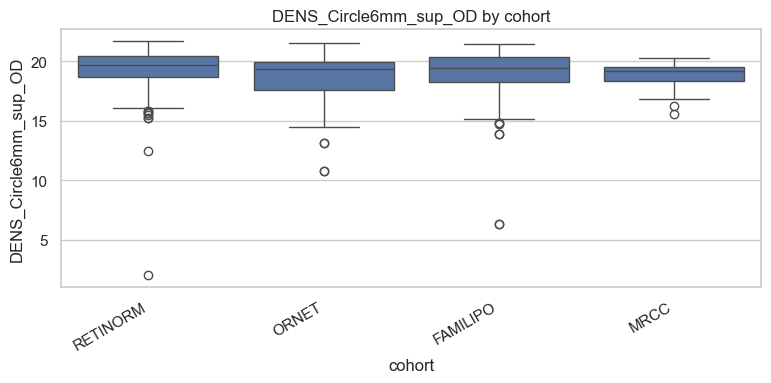

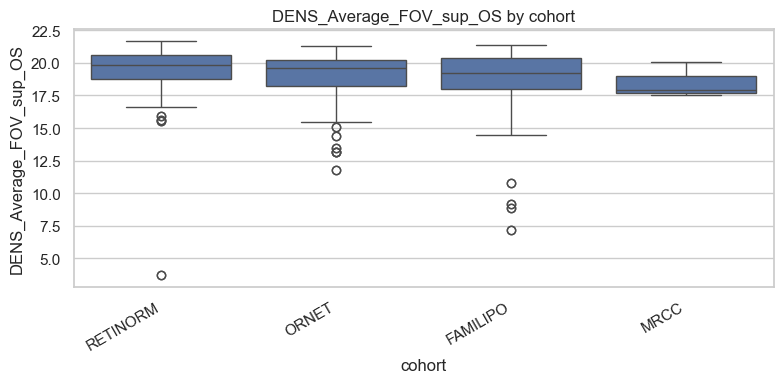

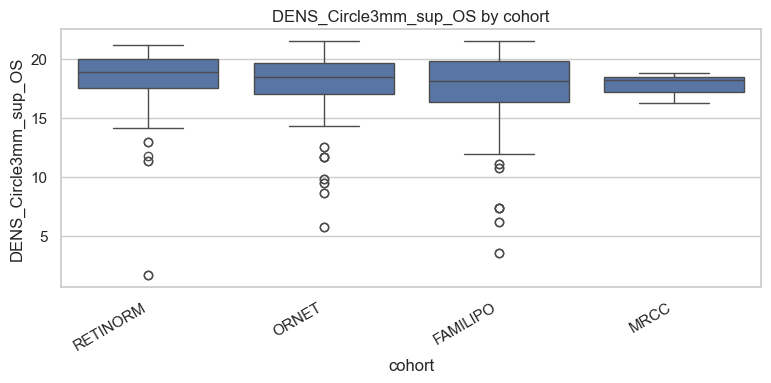

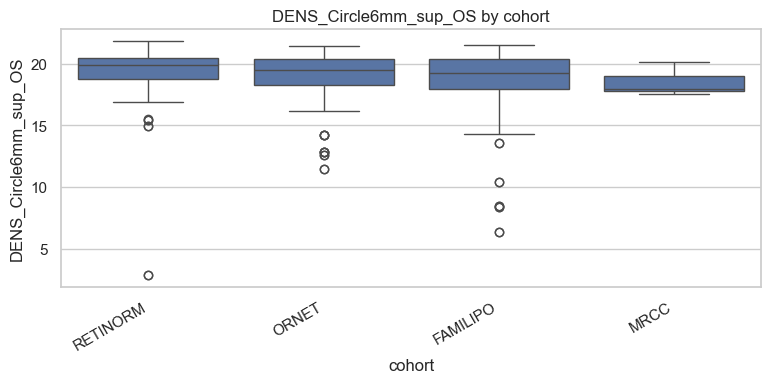

In [10]:
biomarker_pattern = re.compile(r'^(FAZ|Faz|DENS_|PERF_)')
biomarker_cols = [c for c in manifest_clin.columns if biomarker_pattern.search(str(c))]
print('Detected biomarker columns:', len(biomarker_cols))
print(biomarker_cols[:20])

if biomarker_cols:
    biomarker_summary = manifest_clin.groupby('cohort')[biomarker_cols].agg(['count', 'mean', 'std', 'median'])
    biomarker_summary.to_csv(OUTPUT_DIR / 'biomarker_summary_by_cohort.csv')
    display(biomarker_summary.iloc[:, :min(16, biomarker_summary.shape[1])])

    plot_cols = biomarker_cols[:12]
    for col in plot_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=manifest_clin, x='cohort', y=col)
        plt.xticks(rotation=30, ha='right')
        plt.title(f'{col} by cohort')
        plt.tight_layout()
        safe = re.sub(r'[^A-Za-z0-9_.-]+', '_', col)
        plt.savefig(OUTPUT_DIR / f'biomarker_boxplot_{safe}.png', dpi=200)
        plt.show()

In [11]:
patient_level = manifest_clin.drop_duplicates('patient_id').copy()
leakage = patient_level.groupby('patient_id')['cohort'].nunique()
leaked_patients = leakage[leakage > 1].index.tolist()
print('Patients appearing in multiple cohorts:', len(leaked_patients))
print(leaked_patients[:20])

confounder_tables = {}
if 'Age' in patient_level.columns:
    confounder_tables['age_by_cohort'] = patient_level.groupby('cohort')['Age'].describe()
    display(confounder_tables['age_by_cohort'])
if 'Sex' in patient_level.columns:
    confounder_tables['sex_by_cohort'] = pd.crosstab(patient_level['cohort'], patient_level['Sex'], normalize='index')
    display(confounder_tables['sex_by_cohort'])

for name, table in confounder_tables.items():
    table.to_csv(OUTPUT_DIR / f'{name}.csv')

fold_df = assign_patient_folds(manifest_clin, n_splits=5, seed=42, age_col='Age' if 'Age' in manifest_clin else None, sex_col='Sex' if 'Sex' in manifest_clin else None)
validate_patient_folds(fold_df, n_splits=5)
fold_df[['patient_id', 'eye', 'cohort', 'label', 'fold']].to_csv(OUTPUT_DIR / 'preliminary_patient_level_folds.csv', index=False)
display(pd.crosstab(fold_df['fold'], fold_df['cohort']))
print('Zero patient overlap across folds verified.')

Patients appearing in multiple cohorts: 0
[]


,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
FAMILIPO,81.0,52.835447,18.694738,11.547945,41.827397,57.306849,69.172603,79.002740
MRCC,32.0,69.576541,7.014793,49.632877,65.485616,69.554795,73.926027,82.339726
ORNET,77.0,54.350009,12.931747,18.769863,45.175342,55.726027,63.701370,81.964384
RETINORM,75.0,50.361680,20.026573,18.263014,30.431507,54.761644,68.069863,86.939726


Sex,0,1
cohort,,
FAMILIPO,0.530864,0.469136
MRCC,0.843750,0.156250
ORNET,0.454545,0.545455
RETINORM,0.360000,0.640000


C:\Users\BIOMIL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


cohort,FAMILIPO,MRCC,ORNET,RETINORM
fold,,,,
0,30,7,30,26
1,33,7,27,30
2,30,6,32,26
3,33,7,30,26
4,30,7,31,28


Zero patient overlap across folds verified.


In [3]:
# ============================================================
# Phase 2 configuration and optional dependencies
# ============================================================

PHASE2_OUTPUT_DIR = ensure_dir('outputs/phase2_preprocessing')
PHASE2_N_SPLITS = 5
PHASE2_SEED = 42
IMAGE_SIZE = 224

# QC thresholds are intentionally conservative; review Phase 1 image-quality plots before tightening.
QC_MIN_RAW_STD = 1.0
QC_MIN_ROBUST_RANGE = 5.0      # p98 - p2 on raw grayscale [0, 255]
QC_MIN_SNR = 0.05              # mean / std; mainly catches degenerate images
CNN_QUALITY_THRESHOLD = 0.50   # used only if a quality_model_fn is supplied

# Computing fold-wise OCTA mean/std requires reading all training images once per fold.
COMPUTE_PHASE2_PIXEL_STATS = True

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset
except ImportError as e:
    torch = None
    nn = None
    Dataset = object
    print('PyTorch is required for the Dataset/model-facing parts of Phase 2:', e)

try:
    import cv2
except ImportError:
    cv2 = None

try:
    from skimage import exposure
except ImportError:
    exposure = None

try:
    import torchvision.transforms.functional as TVF
    from torchvision.transforms import InterpolationMode
except Exception:
    TVF = None
    InterpolationMode = None

from PIL import ImageEnhance, ImageOps

seed_everything(PHASE2_SEED)
print('PHASE2_OUTPUT_DIR =', PHASE2_OUTPUT_DIR.resolve())

PHASE2_OUTPUT_DIR = C:\Users\BIOMIL\retina-project\outputs\phase2_preprocessing


In [4]:

# ============================================================
# OCTA image QC and deterministic preprocessing
# ============================================================

LAYER_PATH_COLS = {'sup': 'sup_path', 'deep': 'deep_path', 'cc': 'cc_path'}


def read_grayscale_array(path):
    """Read an OCTA image as float32 grayscale in raw 0-255 intensity space."""
    with Image.open(path) as img:
        arr = np.asarray(img.convert('L'), dtype=np.float32)
    return arr


def quick_image_qc(path, min_raw_std=QC_MIN_RAW_STD, min_robust_range=QC_MIN_ROBUST_RANGE,
                   min_snr=QC_MIN_SNR, quality_model_fn=None, cnn_threshold=CNN_QUALITY_THRESHOLD):
    """Lightweight image-quality gate.

    Includes corruption checks, low-contrast/SNR checks, and an optional CNN-quality hook.
    `quality_model_fn(path)` should return a probability-like acceptable-quality score.
    """
    rec = {
        'path': str(path), 'readable': False, 'accepted': False,
        'height': np.nan, 'width': np.nan, 'mean': np.nan, 'std': np.nan,
        'p2': np.nan, 'p98': np.nan, 'robust_range': np.nan, 'snr': np.nan,
        'all_black': False, 'zero_variance': False, 'low_dynamic_range': False,
        'low_snr': False, 'cnn_quality_score': np.nan, 'failed_reason': '',
    }
    try:
        arr = read_grayscale_array(path)
        p2, p98 = np.percentile(arr, [2, 98])
        std = float(arr.std())
        mean = float(arr.mean())
        robust_range = float(p98 - p2)
        snr = float(mean / (std + 1e-6))
        rec.update({
            'readable': True, 'height': int(arr.shape[0]), 'width': int(arr.shape[1]),
            'mean': mean, 'std': std, 'p2': float(p2), 'p98': float(p98),
            'robust_range': robust_range, 'snr': snr,
            'all_black': bool(arr.max() <= 1),
            'zero_variance': bool(std <= min_raw_std),
            'low_dynamic_range': bool(robust_range < min_robust_range),
            'low_snr': bool(snr < min_snr),
        })
        if quality_model_fn is not None:
            score = float(quality_model_fn(path))
            rec['cnn_quality_score'] = score
            if score < cnn_threshold:
                rec['failed_reason'] = 'cnn_quality'
        if not rec['failed_reason']:
            for key in ['all_black', 'zero_variance', 'low_dynamic_range', 'low_snr']:
                if rec[key]:
                    rec['failed_reason'] = key
                    break
        rec['accepted'] = rec['readable'] and not bool(rec['failed_reason'])
    except Exception as e:
        rec['failed_reason'] = f'unreadable: {repr(e)}'
    return rec


def percentile_normalise(arr, lower=2, upper=98):
    lo, hi = np.percentile(arr, [lower, upper])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)
    out = np.clip((arr - lo) / (hi - lo), 0, 1)
    return out.astype(np.float32)


def apply_clahe(arr01, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Apply CLAHE to an image already scaled to [0, 1]."""
    arr01 = np.clip(arr01, 0, 1).astype(np.float32)
    if cv2 is not None:
        u8 = (arr01 * 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        return clahe.apply(u8).astype(np.float32) / 255.0
    if exposure is not None:
        return exposure.equalize_adapthist(arr01, clip_limit=clip_limit / 40.0, nbins=256).astype(np.float32)
    return arr01


def resize_array(arr01, image_size=IMAGE_SIZE, resample=Image.Resampling.BICUBIC):
    img = Image.fromarray((np.clip(arr01, 0, 1) * 255).astype(np.uint8), mode='L')
    img = img.resize((image_size, image_size), resample=resample)
    return np.asarray(img, dtype=np.float32) / 255.0


def preprocess_octa_image(path, image_size=IMAGE_SIZE, use_clahe=True):
    """Raw image -> percentile normalisation -> CLAHE -> resize; output float32 [0, 1]."""
    arr = read_grayscale_array(path)
    arr = percentile_normalise(arr, lower=2, upper=98)
    if use_clahe:
        arr = apply_clahe(arr, clip_limit=2.0, tile_grid_size=(8, 8))
    arr = resize_array(arr, image_size=image_size, resample=Image.Resampling.BICUBIC)
    return arr.astype(np.float32)


def preprocess_mask_image(path, image_size=IMAGE_SIZE):
    if path is None or (isinstance(path, float) and np.isnan(path)) or not Path(path).exists():
        return np.zeros((image_size, image_size), dtype=np.float32)
    arr = read_grayscale_array(path)
    arr = (arr > 0).astype(np.float32)
    return resize_array(arr, image_size=image_size, resample=Image.Resampling.NEAREST)

In [5]:
# ============================================================
# Clinical metadata preprocessing and learnable missing-token layer
# ============================================================

SMOKING_MAP = {
    'never': 0, 'no': 0, 'none': 0, 'non-smoker': 0, 'nonsmoker': 0, '0': 0,
    'former': 1, 'ex': 1, 'past': 1, '1': 1,
    'current': 2, 'yes': 2, 'smoker': 2, 'active': 2, '2': 2,
}
SEX_MAP = {
    'female': 0, 'f': 0, 'woman': 0, '0': 0,
    'male': 1, 'm': 1, 'man': 1, '1': 1,
}


def canonical_feature_name(name):
    return re.sub(r'[^a-z0-9]+', ' ', str(name).strip().lower()).strip()


def infer_clinical_specs(df, clinical_cols):
    """Classify clinical features as continuous, binary, or ordinal."""
    specs = {}
    for col in clinical_cols:
        key = canonical_feature_name(col)
        observed = df[col].dropna() if col in df else pd.Series(dtype='float64')
        unique = set(pd.to_numeric(observed, errors='coerce').dropna().unique().tolist())
        if key in {'age', 'body mass index', 'bmi'} or 'age' == key or 'body mass' in key:
            specs[col] = 'continuous'
        elif 'smoking' in key:
            specs[col] = 'ordinal'
        elif len(unique) <= 2:
            specs[col] = 'binary'
        else:
            specs[col] = 'continuous'
    return specs


class ClinicalPreprocessor:
    """Fold-fitted clinical encoder.

    Continuous variables are z-scored using training-fold statistics.
    Binary variables are encoded as 0/1.
    Ordinal variables (e.g. smoking) are integer-coded for a later learned ordinal token layer.
    Missingness is not imputed statistically; missing values are set to 0 and accompanied by mask=0.
    """
    def __init__(self, clinical_cols, specs=None):
        self.clinical_cols = list(clinical_cols)
        self.specs = dict(specs) if specs is not None else None
        self.continuous_stats = {}
        self.category_maps = {}
        self.ordinal_cardinalities = {}

    def fit(self, df):
        if self.specs is None:
            self.specs = infer_clinical_specs(df, self.clinical_cols)
        for col in self.clinical_cols:
            kind = self.specs[col]
            if kind == 'continuous':
                vals = pd.to_numeric(df[col], errors='coerce')
                mean = float(vals.mean()) if vals.notna().any() else 0.0
                std = float(vals.std(ddof=0)) if vals.notna().any() else 1.0
                if not np.isfinite(std) or std < 1e-6:
                    std = 1.0
                self.continuous_stats[col] = {'mean': mean, 'std': std}
            elif kind == 'ordinal':
                vals = df[col].dropna().map(self._encode_ordinal_value)
                max_code = int(pd.to_numeric(vals, errors='coerce').max()) if len(vals) else 2
                self.ordinal_cardinalities[col] = max(max_code + 1, 3)
            else:
                self.category_maps[col] = self._make_binary_map(df[col])
        return self

    @staticmethod
    def _make_binary_map(series):
        values = [v for v in series.dropna().unique().tolist()]
        if not values:
            return {}
        mapping = {}
        for v in values:
            if isinstance(v, str):
                key = canonical_feature_name(v)
                if key in SEX_MAP:
                    mapping[v] = SEX_MAP[key]
                else:
                    mapping[v] = len(mapping)
            else:
                mapping[v] = int(v)
        return mapping

    @staticmethod
    def _encode_ordinal_value(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, str):
            key = canonical_feature_name(value)
            return SMOKING_MAP.get(key, np.nan)
        return int(value)

    def transform_row(self, row):
        values, mask = [], []
        for col in self.clinical_cols:
            value = row[col] if col in row else np.nan
            if pd.isna(value):
                values.append(0.0)
                mask.append(0.0)
                continue
            kind = self.specs[col]
            if kind == 'continuous':
                value = float(pd.to_numeric(value, errors='coerce'))
                stats = self.continuous_stats[col]
                encoded = (value - stats['mean']) / stats['std'] if np.isfinite(value) else 0.0
            elif kind == 'ordinal':
                encoded = self._encode_ordinal_value(value)
                encoded = 0.0 if pd.isna(encoded) else float(encoded)
            else:
                encoded = self.category_maps.get(col, {}).get(value, value)
                if isinstance(encoded, str):
                    encoded = SEX_MAP.get(canonical_feature_name(encoded), 0)
                encoded = float(encoded)
            values.append(float(encoded))
            mask.append(1.0)
        return np.asarray(values, dtype=np.float32), np.asarray(mask, dtype=np.float32)

    def transform_dataframe(self, df):
        vals, masks = [], []
        for _, row in df.iterrows():
            v, m = self.transform_row(row)
            vals.append(v)
            masks.append(m)
        return np.vstack(vals).astype(np.float32), np.vstack(masks).astype(np.float32)

    @property
    def ordinal_indices(self):
        return [i for i, c in enumerate(self.clinical_cols) if self.specs.get(c) == 'ordinal']

    def to_dict(self):
        return {
            'clinical_cols': self.clinical_cols,
            'specs': self.specs,
            'continuous_stats': self.continuous_stats,
            'category_maps': {str(k): {str(kk): vv for kk, vv in v.items()} for k, v in self.category_maps.items()},
            'ordinal_cardinalities': self.ordinal_cardinalities,
        }

    @classmethod
    def from_dict(cls, state):
        obj = cls(state['clinical_cols'], specs=state['specs'])
        obj.continuous_stats = state.get('continuous_stats', {})
        obj.category_maps = state.get('category_maps', {})
        obj.ordinal_cardinalities = state.get('ordinal_cardinalities', {})
        return obj


if nn is not None:
    class ClinicalMaskTokenImputer(nn.Module):
        """Model-facing learnable imputation layer.

        It converts `(clinical_features, clinical_mask)` into a single D-dimensional vector.
        Missing features receive a trainable scalar token per feature. Ordinal observed
        values can also be passed through a learned scalar embedding instead of being used
        as raw integers.
        """
        def __init__(self, num_features, ordinal_indices=None, ordinal_cardinalities=None):
            super().__init__()
            self.num_features = int(num_features)
            self.missing_tokens = nn.Parameter(torch.zeros(self.num_features))
            self.ordinal_indices = [int(i) for i in (ordinal_indices or [])]
            self.ordinal_embeddings = nn.ModuleDict()
            ordinal_cardinalities = ordinal_cardinalities or {}
            for idx in self.ordinal_indices:
                card = int(ordinal_cardinalities.get(idx, 3))
                self.ordinal_embeddings[str(idx)] = nn.Embedding(card, 1)

        def forward(self, values, mask):
            x = values.float().clone()
            mask = mask.float()
            for idx in self.ordinal_indices:
                if str(idx) in self.ordinal_embeddings:
                    codes = values[:, idx].round().long().clamp(min=0, max=self.ordinal_embeddings[str(idx)].num_embeddings - 1)
                    x[:, idx] = self.ordinal_embeddings[str(idx)](codes).squeeze(-1)
            tokens = self.missing_tokens.view(1, -1).expand_as(x)
            return torch.where(mask > 0.5, x, tokens)
else:
    ClinicalMaskTokenImputer = None


def make_clinical_mask_token_imputer(clinical_preprocessor):
    """Create the model-facing learned missing-token layer for a fitted ClinicalPreprocessor."""
    if ClinicalMaskTokenImputer is None:
        raise ImportError('PyTorch is required for ClinicalMaskTokenImputer')
    ordinal_cardinalities = {
        i: clinical_preprocessor.ordinal_cardinalities.get(col, 3)
        for i, col in enumerate(clinical_preprocessor.clinical_cols)
        if clinical_preprocessor.specs.get(col) == 'ordinal'
    }
    return ClinicalMaskTokenImputer(
        num_features=len(clinical_preprocessor.clinical_cols),
        ordinal_indices=list(ordinal_cardinalities.keys()),
        ordinal_cardinalities=ordinal_cardinalities,
    )

In [6]:
# ============================================================
# Phase 2 fold/QC/statistics utilities
# ============================================================


def build_phase2_manifest(manifest_df, output_dir=PHASE2_OUTPUT_DIR, quality_model_fn=None):
    """Apply per-layer QC and return model-ready rows plus an exclusion log."""
    accepted_rows = []
    qc_rows = []
    for idx, row in manifest_df.reset_index(drop=True).iterrows():
        row_ok = True
        reasons = []
        for layer, col in LAYER_PATH_COLS.items():
            rec = quick_image_qc(row[col], quality_model_fn=quality_model_fn)
            rec.update({'row_index': int(idx), 'patient_id': row['patient_id'], 'eye': row['eye'], 'cohort': row['cohort'], 'layer': layer})
            qc_rows.append(rec)
            if not rec['accepted']:
                row_ok = False
                reasons.append(f'{layer}:{rec["failed_reason"]}')
        if row_ok:
            accepted_rows.append(row.to_dict())
    phase2_df = pd.DataFrame(accepted_rows)
    qc_df = pd.DataFrame(qc_rows)
    exclusions = qc_df[~qc_df['accepted']].copy() if not qc_df.empty else pd.DataFrame()
    phase2_df.to_csv(Path(output_dir) / 'phase2_manifest_qc_pass.csv', index=False)
    qc_df.to_csv(Path(output_dir) / 'phase2_image_qc_full_log.csv', index=False)
    exclusions.to_csv(Path(output_dir) / 'phase2_image_qc_exclusions.csv', index=False)
    return phase2_df, exclusions, qc_df


def compute_layer_stats(df, image_size=IMAGE_SIZE, show_progress=False, desc='Layer statistics'):
    """Compute per-layer mean/std after deterministic preprocessing, using a training fold only."""
    stats = {}
    for layer, col in LAYER_PATH_COLS.items():
        n_pixels = 0
        total = 0.0
        total_sq = 0.0
        paths = df[col].dropna().tolist()
        iterator = paths
        if show_progress and 'phase3_progress' in globals():
            iterator = phase3_progress(paths, desc=f'{desc}: {layer}', unit='image', leave=False)
        for p in iterator:
            arr = preprocess_octa_image(p, image_size=image_size, use_clahe=True)
            total += float(arr.sum())
            total_sq += float((arr ** 2).sum())
            n_pixels += int(arr.size)
        if n_pixels == 0:
            mean, std = 0.0, 1.0
        else:
            mean = total / n_pixels
            var = max(total_sq / n_pixels - mean ** 2, 1e-8)
            std = float(np.sqrt(var))
        stats[layer] = {'mean': float(mean), 'std': float(std), 'n_pixels': int(n_pixels)}
    return stats


def compute_clinical_mutual_information(df, clinical_preprocessor, label_col='label'):
    try:
        from sklearn.feature_selection import mutual_info_classif
    except Exception as e:
        print('Skipping mutual information; sklearn is unavailable:', e)
        return pd.DataFrame()
    values, masks = clinical_preprocessor.transform_dataframe(df)
    # Include missingness indicators in MI because missingness can itself be clinically informative.
    x = np.concatenate([values, masks], axis=1)
    y = df[label_col].astype(int).to_numpy()
    mi = mutual_info_classif(x, y, discrete_features=False, random_state=PHASE2_SEED)
    feature_names = clinical_preprocessor.clinical_cols + [f'{c}__observed_mask' for c in clinical_preprocessor.clinical_cols]
    out = pd.DataFrame({'feature': feature_names, 'mutual_information': mi})
    out['low_information_flag'] = out['mutual_information'] < 0.01
    return out.sort_values('mutual_information', ascending=False).reset_index(drop=True)


def validate_no_patient_overlap_between_splits(train_df, val_df):
    train_patients = set(train_df['patient_id'].astype(str))
    val_patients = set(val_df['patient_id'].astype(str))
    overlap = sorted(train_patients & val_patients)
    if overlap:
        raise AssertionError(f'Patient overlap between train/val: {overlap[:10]}')
    return True

In [7]:
# ============================================================
# PyTorch Dataset with synchronized OCTA augmentation
# ============================================================


def _array_to_pil(arr01):
    return Image.fromarray((np.clip(arr01, 0, 1) * 255).astype(np.uint8), mode='L')


def _pil_to_array(img):
    return np.asarray(img.convert('L'), dtype=np.float32) / 255.0


def sample_octa_augmentation_params(rng):
    return {
        'hflip': bool(rng.random() < 0.5),
        'vflip': bool(rng.random() < 0.3),
        'angle': float(rng.uniform(-15, 15)),
        'translate': (int(rng.integers(-11, 12)), int(rng.integers(-11, 12))),  # ~5% of 224
        'scale': float(rng.uniform(0.95, 1.05)),
        'shear': float(rng.uniform(-5, 5)),
        'brightness': float(rng.uniform(0.9, 1.1)),
        'contrast': float(rng.uniform(0.9, 1.1)),
        'noise': bool(rng.random() < 0.2),
        'noise_sigma': 0.01,
    }


def apply_octa_group_augmentation(arrays, params):
    """Apply the same geometric transform to Sup/Deep/CC to preserve correspondence."""
    out = []
    for arr in arrays:
        img = _array_to_pil(arr)
        if params['hflip']:
            img = ImageOps.mirror(img)
        if params['vflip']:
            img = ImageOps.flip(img)
        if TVF is not None:
            img = TVF.affine(
                img, angle=params['angle'], translate=params['translate'], scale=params['scale'],
                shear=[params['shear'], 0.0], interpolation=InterpolationMode.BICUBIC, fill=0
            )
        else:
            img = img.rotate(params['angle'], resample=Image.Resampling.BICUBIC, fillcolor=0)
            tx, ty = params['translate']
            img = img.transform(img.size, Image.Transform.AFFINE, (1, 0, -tx, 0, 1, -ty),
                                resample=Image.Resampling.BICUBIC, fillcolor=0)
        img = ImageEnhance.Brightness(img).enhance(params['brightness'])
        img = ImageEnhance.Contrast(img).enhance(params['contrast'])
        aug = _pil_to_array(img)
        if params['noise']:
            aug = np.clip(aug + np.random.normal(0, params['noise_sigma'], size=aug.shape), 0, 1)
        out.append(aug.astype(np.float32))
    return out


class RastaPhase2Dataset(Dataset):
    """RASTA eye-level Dataset.

    Returns the dictionary specified in Phase 2. Missing clinical values are represented by
    `clinical_mask=0` and should be converted to learned mask tokens inside the model via
    `ClinicalMaskTokenImputer`.
    """
    def __init__(self, df, clinical_preprocessor, layer_stats, train=False, image_size=IMAGE_SIZE,
                 clinical_mask_dropout=0.10, mask_path_cols=None, seed=PHASE2_SEED):
        if torch is None:
            raise ImportError('PyTorch is required to instantiate RastaPhase2Dataset')
        self.df = df.reset_index(drop=True).copy()
        self.clinical_preprocessor = clinical_preprocessor
        self.layer_stats = layer_stats
        self.train = bool(train)
        self.image_size = int(image_size)
        self.clinical_mask_dropout = float(clinical_mask_dropout)
        self.mask_path_cols = mask_path_cols or {'vessel_mask': None, 'faz_mask': None, 'flow_mask': None}
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.df)

    def _load_layer(self, row, layer):
        arr = preprocess_octa_image(row[LAYER_PATH_COLS[layer]], image_size=self.image_size, use_clahe=True)
        return arr

    def _standardize_layer(self, arr, layer):
        mean = float(self.layer_stats[layer]['mean'])
        std = float(self.layer_stats[layer]['std'])
        return ((arr - mean) / max(std, 1e-6)).astype(np.float32)

    def _load_optional_mask(self, row, key):
        col = self.mask_path_cols.get(key)
        path = row[col] if col and col in row and pd.notna(row[col]) else None
        arr = preprocess_mask_image(path, image_size=self.image_size)
        return torch.from_numpy(arr[None, :, :].astype(np.float32))

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arrays = [self._load_layer(row, layer) for layer in ['sup', 'deep', 'cc']]
        if self.train:
            params = sample_octa_augmentation_params(self.rng)
            arrays = apply_octa_group_augmentation(arrays, params)
        sup, deep, cc = [self._standardize_layer(arr, layer) for arr, layer in zip(arrays, ['sup', 'deep', 'cc'])]

        clinical_values, clinical_mask = self.clinical_preprocessor.transform_row(row)
        if self.train and self.clinical_mask_dropout > 0:
            observed = np.where(clinical_mask > 0.5)[0]
            if len(observed):
                drop = observed[self.rng.random(len(observed)) < self.clinical_mask_dropout]
                clinical_values[drop] = 0.0
                clinical_mask[drop] = 0.0

        sample = {
            'sup_image': torch.from_numpy(sup[None, :, :]),
            'deep_image': torch.from_numpy(deep[None, :, :]),
            'cc_image': torch.from_numpy(cc[None, :, :]),
            'clinical_features': torch.from_numpy(clinical_values.astype(np.float32)),
            'clinical_mask': torch.from_numpy(clinical_mask.astype(np.float32)),
            'vessel_mask': self._load_optional_mask(row, 'vessel_mask'),
            'faz_mask': self._load_optional_mask(row, 'faz_mask'),
            'flow_mask': self._load_optional_mask(row, 'flow_mask'),
            'label': torch.tensor(int(row['label']), dtype=torch.long),
            'patient_id': str(row['patient_id']),
            'eye': str(row['eye']),
            'fold': int(row['fold']) if 'fold' in row else -1,
        }
        return sample


def make_phase2_datasets_for_fold(fold_df, fold, clinical_preprocessor, layer_stats, **dataset_kwargs):
    train_df = fold_df[fold_df['fold'] != fold].copy()
    val_df = fold_df[fold_df['fold'] == fold].copy()
    validate_no_patient_overlap_between_splits(train_df, val_df)
    train_ds = RastaPhase2Dataset(train_df, clinical_preprocessor, layer_stats, train=True, **dataset_kwargs)
    val_ds = RastaPhase2Dataset(val_df, clinical_preprocessor, layer_stats, train=False, **dataset_kwargs)
    return train_ds, val_ds

In [ ]:
# ============================================================
# Build Phase 2 artifacts: QC-passed manifest, patient folds, clinical processors, fold stats
# ============================================================

if 'manifest_clin' not in globals():
    raise RuntimeError('Run Phase 1 cells first so manifest_clin is available.')

phase2_manifest, phase2_exclusions, phase2_qc_log = build_phase2_manifest(manifest_clin, output_dir=PHASE2_OUTPUT_DIR)
print('QC-passed eye rows:', phase2_manifest.shape)
print('Excluded layer images:', phase2_exclusions.shape)

phase2_folds = assign_patient_folds(
    phase2_manifest,
    n_splits=PHASE2_N_SPLITS,
    seed=PHASE2_SEED,
    age_col='Age' if 'Age' in phase2_manifest.columns else None,
    sex_col='Sex' if 'Sex' in phase2_manifest.columns else None,
)
validate_patient_folds(phase2_folds, n_splits=PHASE2_N_SPLITS)
phase2_folds.to_csv(PHASE2_OUTPUT_DIR / 'phase2_patient_stratified_folds.csv', index=False)

display(pd.crosstab(phase2_folds['fold'], phase2_folds['cohort']))
print('Zero patient overlap across folds verified for Phase 2.')

clinical_cols_phase2 = default_clinical_columns(phase2_folds)
save_json({'clinical_cols': clinical_cols_phase2}, PHASE2_OUTPUT_DIR / 'phase2_clinical_columns.json')

clinical_preprocessors = {}
layer_stats_by_fold = {}
mi_tables = []

for fold in range(PHASE2_N_SPLITS):
    train_df = phase2_folds[phase2_folds['fold'] != fold].copy()
    val_df = phase2_folds[phase2_folds['fold'] == fold].copy()
    validate_no_patient_overlap_between_splits(train_df, val_df)

    clinical_pre = ClinicalPreprocessor(clinical_cols_phase2).fit(train_df)
    clinical_preprocessors[fold] = clinical_pre
    save_json(clinical_pre.to_dict(), PHASE2_OUTPUT_DIR / f'clinical_preprocessor_fold{fold}.json')

    mi = compute_clinical_mutual_information(train_df, clinical_pre)
    if not mi.empty:
        mi.insert(0, 'fold', fold)
        mi.to_csv(PHASE2_OUTPUT_DIR / f'clinical_mutual_information_fold{fold}.csv', index=False)
        mi_tables.append(mi)

    if COMPUTE_PHASE2_PIXEL_STATS:
        stats = compute_layer_stats(train_df, image_size=IMAGE_SIZE)
    else:
        stats = {layer: {'mean': 0.0, 'std': 1.0, 'n_pixels': 0} for layer in LAYER_PATH_COLS}
    layer_stats_by_fold[fold] = stats
    save_json(stats, PHASE2_OUTPUT_DIR / f'octa_train_stats_fold{fold}.json')

if mi_tables:
    pd.concat(mi_tables, ignore_index=True).to_csv(PHASE2_OUTPUT_DIR / 'clinical_mutual_information_all_folds.csv', index=False)

save_json(layer_stats_by_fold, PHASE2_OUTPUT_DIR / 'octa_train_stats_all_folds.json')

print('Phase 2 artifacts saved to:', PHASE2_OUTPUT_DIR.resolve())
print('Example fold 0 layer stats:')
print(json.dumps(layer_stats_by_fold.get(0, {}), indent=2))

if torch is not None and len(phase2_folds):
    # Smoke-test construction only; indexing loads images, so leave actual sample loading to the GPU/data machine.
    train_ds0, val_ds0 = make_phase2_datasets_for_fold(
        phase2_folds, fold=0, clinical_preprocessor=clinical_preprocessors[0], layer_stats=layer_stats_by_fold[0]
    )
    print('Fold 0 dataset sizes:', len(train_ds0), 'train /', len(val_ds0), 'val')
    print('Clinical feature dimension:', len(clinical_cols_phase2))

QC-passed eye rows: (476, 51)
Excluded layer images: (0, 22)


C:\Users\BIOMIL\retina-project\.venv\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


cohort,FAMILIPO,MRCC,ORNET,RETINORM
fold,,,,
0,29,8,32,25
1,28,6,31,28
2,38,6,25,29
3,28,8,31,27
4,33,6,31,27


Zero patient overlap across folds verified for Phase 2.


In [ ]:
# ============================================================
# Phase 3 configuration: OCTA-SimCLR pretraining
# ============================================================

PHASE3_OUTPUT_DIR = ensure_dir('outputs/phase3_octa_simclr')
PHASE3_SEED = 42
PHASE3_IMAGE_SIZE = IMAGE_SIZE
PHASE3_LAYERS = ['sup', 'deep', 'cc']

# Publication-conservative default: pretrain within each downstream training fold only.
# Optional transductive/self-supervised mode: set to 'all_qc_pass' to use all QC-passed OCTA images label-free.
PHASE3_PRETRAIN_SCOPE = 'fold_train'  # {'fold_train', 'all_qc_pass'}

# Expensive CUDA job. Keep False while editing here; set True on the CUDA GPU machine to launch Phase 3.
RUN_PHASE3_PRETRAINING = False
PHASE3_REQUIRE_CUDA = True
PHASE3_FOLDS_TO_RUN = list(range(PHASE2_N_SPLITS))  # used when PHASE3_PRETRAIN_SCOPE == 'fold_train'
PHASE3_LAYERS_TO_RUN = PHASE3_LAYERS

# SimCLR hyperparameters from PLAN.md Phase 3.
PHASE3_EPOCHS = 100
PHASE3_BATCH_SIZE = 256
PHASE3_GRAD_ACCUM_STEPS = 1          # increase if GPU memory requires smaller physical batches
PHASE3_NUM_WORKERS = 4
PHASE3_TEMPERATURE = 0.07
PHASE3_LR = 0.1
PHASE3_MOMENTUM = 0.9
PHASE3_WEIGHT_DECAY = 1e-4
PHASE3_USE_AMP = True
PHASE3_IMAGENET_INIT = True
PHASE3_CHECKPOINT_EVERY = 10
PHASE3_SHOW_PROGRESS = True              # live notebook progress bars for Phase 3 launch/training
PHASE3_SHOW_BATCH_PROGRESS = True        # set False for quieter output; epoch bar still shows per-epoch timing
PHASE3_PROGRESS_UPDATE_EVERY = 10        # batch progress postfix update cadence

if torch is None:
    raise ImportError('PyTorch is required for Phase 3 OCTA-SimCLR pretraining.')

import math
import time
from PIL import ImageFilter
from torch.utils.data import DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    class _NoOpProgress:
        """Minimal tqdm-compatible fallback if tqdm is unavailable."""
        def __init__(self, iterable=None, total=None, desc=None, unit=None, **kwargs):
            self.iterable = iterable
            self.total = total
            self.desc = desc or 'progress'
            self.unit = unit or 'it'
            self.n = 0
            self.disable = kwargs.get('disable', False)
            if iterable is None and not self.disable:
                print(f'{self.desc}: started' + (f' (total={total} {self.unit})' if total is not None else ''))

        def __iter__(self):
            if self.iterable is None:
                return iter(())
            if not self.disable:
                print(f'{self.desc}: started')
            for item in self.iterable:
                yield item
            if not self.disable:
                print(f'{self.desc}: done')

        def update(self, n=1):
            self.n += n
            if not self.disable and self.total is not None:
                print(f'{self.desc}: {self.n}/{self.total} {self.unit}')

        def set_postfix(self, *args, **kwargs):
            return None

        def set_description_str(self, desc):
            self.desc = desc

        def close(self):
            if not self.disable:
                print(f'{self.desc}: done')

    def tqdm(iterable=None, *args, **kwargs):
        return _NoOpProgress(iterable=iterable, **kwargs)


def format_duration(seconds):
    seconds = max(0.0, float(seconds))
    if seconds < 60:
        return f'{seconds:.1f}s'
    minutes, sec = divmod(seconds, 60)
    if minutes < 60:
        return f'{int(minutes)}m {sec:04.1f}s'
    hours, minutes = divmod(minutes, 60)
    return f'{int(hours)}h {int(minutes):02d}m {sec:04.1f}s'


def phase3_progress(iterable=None, **kwargs):
    """tqdm wrapper controlled by PHASE3_SHOW_PROGRESS."""
    kwargs.setdefault('dynamic_ncols', True)
    kwargs['disable'] = bool(kwargs.get('disable', False) or not PHASE3_SHOW_PROGRESS)
    return tqdm(iterable, **kwargs)

try:
    from torchvision import models
except Exception as e:
    models = None
    print('torchvision.models unavailable; ConvNeXt-Tiny cannot be constructed until this is fixed:', repr(e))

seed_everything(PHASE3_SEED)
print('PHASE3_OUTPUT_DIR =', PHASE3_OUTPUT_DIR.resolve())
print('RUN_PHASE3_PRETRAINING =', RUN_PHASE3_PRETRAINING)
print('PHASE3_REQUIRE_CUDA =', PHASE3_REQUIRE_CUDA)
print('PHASE3_PRETRAIN_SCOPE =', PHASE3_PRETRAIN_SCOPE)


In [ ]:
# ============================================================
# Phase 3 positive-pair dataset and conservative OCTA augmentations
# ============================================================


def sample_simclr_augmentation_params(rng=np.random):
    """Conservative SimCLR augmentation that preserves OCTA vascular morphology."""
    return {
        'hflip': bool(rng.random() < 0.5),
        'rotate': bool(rng.random() < 0.4),
        'angle': float(rng.uniform(-15.0, 15.0)),
        'crop_scale': float(rng.uniform(0.70, 1.00)),
        'blur': bool(rng.random() < 0.3),
        'blur_sigma': float(rng.uniform(0.1, 2.0)),
        'brightness': float(rng.uniform(0.90, 1.10)),
        'contrast': float(rng.uniform(0.90, 1.10)),
    }


def apply_simclr_augmentation(arr01, params, image_size=PHASE3_IMAGE_SIZE):
    """Apply one independently sampled SimCLR view transform to a preprocessed [0,1] OCTA array."""
    img = _array_to_pil(arr01)

    # Random resized crop, implemented before other transforms.
    w, h = img.size
    crop_size = max(1, int(round(min(w, h) * params['crop_scale'])))
    if crop_size < min(w, h):
        left = int(np.random.randint(0, w - crop_size + 1))
        top = int(np.random.randint(0, h - crop_size + 1))
        img = img.crop((left, top, left + crop_size, top + crop_size))
    img = img.resize((image_size, image_size), resample=Image.Resampling.BICUBIC)

    if params['hflip']:
        img = ImageOps.mirror(img)
    if params['rotate']:
        img = img.rotate(params['angle'], resample=Image.Resampling.BICUBIC, fillcolor=0)
    if params['blur']:
        img = img.filter(ImageFilter.GaussianBlur(radius=params['blur_sigma']))

    img = ImageEnhance.Brightness(img).enhance(params['brightness'])
    img = ImageEnhance.Contrast(img).enhance(params['contrast'])
    return _pil_to_array(img).astype(np.float32)


def standardize_octa_array(arr01, layer, layer_stats):
    mean = float(layer_stats[layer]['mean']) if layer_stats and layer in layer_stats else 0.0
    std = float(layer_stats[layer]['std']) if layer_stats and layer in layer_stats else 1.0
    return ((arr01 - mean) / max(std, 1e-6)).astype(np.float32)


def simclr_tensor_from_path(path, layer, layer_stats, augment=True, image_size=PHASE3_IMAGE_SIZE):
    arr = preprocess_octa_image(path, image_size=image_size, use_clahe=True)
    if augment:
        arr = apply_simclr_augmentation(arr, sample_simclr_augmentation_params(), image_size=image_size)
    arr = standardize_octa_array(arr, layer, layer_stats)
    return torch.from_numpy(arr[None, :, :].astype(np.float32))


class RastaSimCLRLayerDataset(Dataset):
    """Layer-specific SimCLR Dataset using OD/OS as natural positives when available.

    For patients with both eyes: view1 and view2 are the same OCTA layer from opposite eyes.
    For unilateral patients: view1 and view2 are two independent augmentations of the same image.
    """
    def __init__(self, df, layer, layer_stats, image_size=PHASE3_IMAGE_SIZE):
        if layer not in LAYER_PATH_COLS:
            raise ValueError(f'Unknown OCTA layer: {layer}')
        self.df = df.reset_index(drop=True).copy()
        self.layer = layer
        self.path_col = LAYER_PATH_COLS[layer]
        self.layer_stats = layer_stats
        self.image_size = int(image_size)
        self.eye_path_by_patient = {}
        for patient_id, g in self.df.groupby('patient_id'):
            eye_map = {}
            for _, row in g.iterrows():
                if pd.notna(row.get(self.path_col)):
                    eye_map[str(row['eye'])] = str(row[self.path_col])
            self.eye_path_by_patient[str(patient_id)] = eye_map

    def __len__(self):
        return len(self.df)

    def _positive_path(self, row):
        patient_id = str(row['patient_id'])
        eye = str(row['eye'])
        eye_map = self.eye_path_by_patient.get(patient_id, {})
        opposite_eye = 'OS' if eye == 'OD' else 'OD'
        if opposite_eye in eye_map:
            return eye_map[opposite_eye], opposite_eye, 'bilateral_od_os'
        return str(row[self.path_col]), eye, 'self_augmented_unilateral'

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path1 = str(row[self.path_col])
        path2, eye2, positive_type = self._positive_path(row)
        x1 = simclr_tensor_from_path(path1, self.layer, self.layer_stats, augment=True, image_size=self.image_size)
        x2 = simclr_tensor_from_path(path2, self.layer, self.layer_stats, augment=True, image_size=self.image_size)
        return {
            'view1': x1,
            'view2': x2,
            'patient_id': str(row['patient_id']),
            'eye1': str(row['eye']),
            'eye2': str(eye2),
            'layer': self.layer,
            'positive_type': positive_type,
        }


def summarize_simclr_pairs(df):
    rows = []
    for layer, path_col in LAYER_PATH_COLS.items():
        n_rows = int(df[path_col].notna().sum())
        bilateral_eye_rows = 0
        unilateral_eye_rows = 0
        bilateral_patients = 0
        unilateral_patients = 0
        for _, g in df.groupby('patient_id'):
            eyes = set(g.loc[g[path_col].notna(), 'eye'].astype(str))
            if {'OD', 'OS'}.issubset(eyes):
                bilateral_patients += 1
                bilateral_eye_rows += int(g[path_col].notna().sum())
            elif len(eyes) == 1:
                unilateral_patients += 1
                unilateral_eye_rows += int(g[path_col].notna().sum())
        rows.append({
            'layer': layer,
            'eye_rows': n_rows,
            'bilateral_positive_eye_rows': bilateral_eye_rows,
            'self_augmented_eye_rows': unilateral_eye_rows,
            'bilateral_patients': bilateral_patients,
            'unilateral_patients': unilateral_patients,
        })
    return pd.DataFrame(rows)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [ ]:
# ============================================================
# Phase 3 ConvNeXt-Tiny SimCLR model and NT-Xent loss
# ============================================================


class ConvNeXtTinyBackbone(nn.Module):
    """ConvNeXt-Tiny feature extractor adapted to 1-channel OCTA input."""
    output_dim = 768

    def __init__(self, in_chans=1, imagenet_init=True):
        super().__init__()
        if models is None:
            raise ImportError('torchvision.models is required to build ConvNeXt-Tiny.')
        weights = None
        if imagenet_init:
            try:
                weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
            except Exception:
                weights = 'IMAGENET1K_V1'
        try:
            backbone = models.convnext_tiny(weights=weights)
        except Exception as e:
            print('Warning: failed to load ImageNet ConvNeXt-Tiny weights; falling back to random init:', repr(e))
            backbone = models.convnext_tiny(weights=None)
        self.features = backbone.features
        self._adapt_first_conv(in_chans=in_chans)

    def _adapt_first_conv(self, in_chans=1):
        stem_conv = self.features[0][0]
        if not isinstance(stem_conv, nn.Conv2d) or stem_conv.in_channels == in_chans:
            return
        new_conv = nn.Conv2d(
            in_chans,
            stem_conv.out_channels,
            kernel_size=stem_conv.kernel_size,
            stride=stem_conv.stride,
            padding=stem_conv.padding,
            dilation=stem_conv.dilation,
            groups=1,
            bias=stem_conv.bias is not None,
            padding_mode=stem_conv.padding_mode,
        )
        with torch.no_grad():
            if in_chans == 1 and stem_conv.weight.shape[1] == 3:
                new_conv.weight.copy_(stem_conv.weight.mean(dim=1, keepdim=True))
            else:
                nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
            if stem_conv.bias is not None:
                new_conv.bias.copy_(stem_conv.bias)
        self.features[0][0] = new_conv

    def forward_features(self, x):
        return self.features(x)

    def forward(self, x):
        fmap = self.forward_features(x)
        return fmap.mean(dim=(-2, -1))


class OCTASimCLR(nn.Module):
    """ConvNeXt-Tiny encoder plus 2-layer SimCLR projection head."""
    def __init__(self, projection_hidden=256, projection_dim=128, imagenet_init=True):
        super().__init__()
        self.encoder = ConvNeXtTinyBackbone(in_chans=1, imagenet_init=imagenet_init)
        self.projector = nn.Sequential(
            nn.Linear(self.encoder.output_dim, projection_hidden),
            nn.GELU(),
            nn.Linear(projection_hidden, projection_dim),
        )

    def forward(self, x, return_features=False):
        h = self.encoder(x)
        z = nn.functional.normalize(self.projector(h), dim=1)
        if return_features:
            return h, z
        return z


def nt_xent_loss(z1, z2, temperature=PHASE3_TEMPERATURE):
    """Normalized temperature-scaled cross entropy for paired batches."""
    if z1.shape != z2.shape:
        raise ValueError(f'z1 and z2 must have identical shapes, got {z1.shape} and {z2.shape}')
    batch_size = z1.size(0)
    if batch_size < 2:
        raise ValueError('NT-Xent requires batch_size >= 2')
    z = torch.cat([z1, z2], dim=0)
    sim = torch.matmul(z, z.T) / float(temperature)
    self_mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    mask_value = torch.finfo(sim.dtype).min if sim.is_floating_point() else -1e9
    sim = sim.masked_fill(self_mask, mask_value)
    targets = torch.arange(2 * batch_size, device=z.device)
    targets = (targets + batch_size) % (2 * batch_size)
    return nn.functional.cross_entropy(sim, targets)


def make_grad_scaler(enabled):
    try:
        return torch.amp.GradScaler('cuda', enabled=enabled)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context(device, enabled):
    try:
        return torch.amp.autocast(device_type=device.type, enabled=enabled)
    except Exception:
        return torch.cuda.amp.autocast(enabled=enabled)


In [ ]:
# ============================================================
# Phase 3 data selection, statistics, checkpoint paths, and training loop
# ============================================================


def get_phase3_pretraining_df(fold=None, scope=PHASE3_PRETRAIN_SCOPE):
    """Return unlabeled eye rows for SimCLR pretraining.

    scope='fold_train': only rows outside the held-out fold, avoiding validation/test image exposure.
    scope='all_qc_pass': all QC-passed rows, label-free transductive self-supervised pretraining.
    """
    if 'phase2_folds' not in globals():
        raise RuntimeError('Run Phase 2 artifact cell first so phase2_folds is available.')
    if scope == 'fold_train':
        if fold is None:
            raise ValueError('fold must be provided when scope="fold_train"')
        df = phase2_folds[phase2_folds['fold'] != fold].copy()
    elif scope == 'all_qc_pass':
        df = phase2_folds.copy()
    else:
        raise ValueError(f'Unknown PHASE3_PRETRAIN_SCOPE: {scope}')
    missing = [col for col in LAYER_PATH_COLS.values() if col not in df.columns]
    if missing:
        raise ValueError(f'Missing layer path columns for Phase 3: {missing}')
    return df.reset_index(drop=True)


def phase3_stats_cache_path(fold=None, scope=PHASE3_PRETRAIN_SCOPE):
    tag = f'{scope}_fold{fold}' if scope == 'fold_train' else scope
    return PHASE3_OUTPUT_DIR / f'octa_simclr_stats_{tag}.json'


def get_phase3_layer_stats(pretrain_df, fold=None, scope=PHASE3_PRETRAIN_SCOPE):
    if scope == 'fold_train' and 'layer_stats_by_fold' in globals() and fold in layer_stats_by_fold:
        return layer_stats_by_fold[fold]
    path = phase3_stats_cache_path(fold=fold, scope=scope)
    if path.exists():
        return json.loads(path.read_text())
    tag = f'{scope}_fold{fold}' if scope == 'fold_train' else scope
    try:
        stats = compute_layer_stats(
            pretrain_df,
            image_size=PHASE3_IMAGE_SIZE,
            show_progress=PHASE3_SHOW_PROGRESS,
            desc=f'Phase 3 stats {tag}',
        )
    except TypeError:
        # Backward-compatible if an older in-memory compute_layer_stats was not rerun.
        stats = compute_layer_stats(pretrain_df, image_size=PHASE3_IMAGE_SIZE)
    save_json(stats, path)
    return stats


def phase3_checkpoint_prefix(layer, fold=None, scope=PHASE3_PRETRAIN_SCOPE):
    tag = f'{scope}_fold{fold}' if scope == 'fold_train' else scope
    return PHASE3_OUTPUT_DIR / f'simclr_{tag}_{layer}'


def save_simclr_checkpoint(model, optimizer, scheduler, epoch, history, layer, fold, scope, layer_stats, is_best=False):
    prefix = phase3_checkpoint_prefix(layer, fold=fold, scope=scope)
    checkpoint_path = Path(str(prefix) + ('_best.pt' if is_best else '_last.pt'))
    payload = {
        'epoch': int(epoch),
        'layer': layer,
        'fold': None if fold is None else int(fold),
        'scope': scope,
        'model_state_dict': model.state_dict(),
        'encoder_state_dict': model.encoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else None,
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'history': history,
        'layer_stats': layer_stats,
        'config': {
            'epochs': PHASE3_EPOCHS,
            'batch_size': PHASE3_BATCH_SIZE,
            'grad_accum_steps': PHASE3_GRAD_ACCUM_STEPS,
            'temperature': PHASE3_TEMPERATURE,
            'lr': PHASE3_LR,
            'momentum': PHASE3_MOMENTUM,
            'weight_decay': PHASE3_WEIGHT_DECAY,
            'imagenet_init': PHASE3_IMAGENET_INIT,
            'require_cuda': PHASE3_REQUIRE_CUDA,
        },
    }
    torch.save(payload, checkpoint_path)
    return checkpoint_path


def save_simclr_backbone(model, layer, fold, scope, layer_stats, history):
    prefix = phase3_checkpoint_prefix(layer, fold=fold, scope=scope)
    backbone_path = Path(str(prefix) + '_backbone.pt')
    payload = {
        'layer': layer,
        'fold': None if fold is None else int(fold),
        'scope': scope,
        'encoder_state_dict': model.encoder.state_dict(),
        'layer_stats': layer_stats,
        'history': history,
        'output_dim': model.encoder.output_dim,
        'note': 'Projection head discarded; load encoder_state_dict into ConvNeXtTinyBackbone for Phase 4.',
    }
    torch.save(payload, backbone_path)
    return backbone_path


def train_simclr_one_layer(layer, pretrain_df, layer_stats, fold=None, scope=PHASE3_PRETRAIN_SCOPE, resume_path=None):
    if len(pretrain_df) < 2:
        raise ValueError(f'Need at least 2 eye rows for SimCLR pretraining, got {len(pretrain_df)}')

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if PHASE3_REQUIRE_CUDA and device.type != 'cuda':
        raise RuntimeError('Phase 3 is configured for the CUDA-enabled training machine, but CUDA is not available in this runtime.')
    amp_enabled = bool(PHASE3_USE_AMP and device.type == 'cuda')
    dataset = RastaSimCLRLayerDataset(pretrain_df, layer=layer, layer_stats=layer_stats, image_size=PHASE3_IMAGE_SIZE)
    generator = torch.Generator()
    generator.manual_seed(PHASE3_SEED)
    loader = DataLoader(
        dataset,
        batch_size=PHASE3_BATCH_SIZE,
        shuffle=True,
        num_workers=PHASE3_NUM_WORKERS,
        pin_memory=(device.type == 'cuda'),
        drop_last=(len(dataset) >= PHASE3_BATCH_SIZE),
        worker_init_fn=seed_worker,
        generator=generator,
    )
    if len(loader) == 0:
        raise ValueError('DataLoader has zero batches; reduce PHASE3_BATCH_SIZE or add more data.')

    model = OCTASimCLR(imagenet_init=PHASE3_IMAGENET_INIT).to(device)
    optimizer = torch.optim.SGD(
        model.parameters(), lr=PHASE3_LR, momentum=PHASE3_MOMENTUM, weight_decay=PHASE3_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE3_EPOCHS, eta_min=0.0)
    scaler = make_grad_scaler(amp_enabled)
    start_epoch = 1
    history = []
    best_loss = float('inf')

    if resume_path is not None and Path(resume_path).exists():
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        if ckpt.get('optimizer_state_dict') is not None:
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        if ckpt.get('scheduler_state_dict') is not None:
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        history = list(ckpt.get('history', []))
        start_epoch = int(ckpt.get('epoch', 0)) + 1
        if history:
            best_loss = min(float(h['loss']) for h in history)
        print(f'Resumed {layer} SimCLR from {resume_path} at epoch {start_epoch}')

    print(f'Phase 3 SimCLR | layer={layer} fold={fold} scope={scope} device={device} n={len(dataset)} batches={len(loader)}')
    run_t0 = time.time()
    remaining_epochs = max(0, PHASE3_EPOCHS - start_epoch + 1)
    epoch_bar = phase3_progress(
        range(start_epoch, PHASE3_EPOCHS + 1),
        total=remaining_epochs,
        desc=f'Phase 3 {scope} fold={fold} layer={layer}',
        unit='epoch',
        leave=True,
    )
    for epoch in epoch_bar:
        model.train()
        t0 = time.time()
        running_loss = 0.0
        optimizer.zero_grad(set_to_none=True)
        valid_steps = 0

        batch_bar = phase3_progress(
            enumerate(loader, start=1),
            total=len(loader),
            desc=f'{layer} epoch {epoch:03d}/{PHASE3_EPOCHS}',
            unit='batch',
            leave=False,
            disable=(not PHASE3_SHOW_BATCH_PROGRESS),
        )
        for step, batch in batch_bar:
            x1 = batch['view1'].to(device, non_blocking=True)
            x2 = batch['view2'].to(device, non_blocking=True)
            if x1.size(0) < 2:
                continue
            with autocast_context(device, amp_enabled):
                z1 = model(x1)
                z2 = model(x2)
                loss = nt_xent_loss(z1, z2, temperature=PHASE3_TEMPERATURE)
                scaled_loss = loss / max(1, PHASE3_GRAD_ACCUM_STEPS)
            scaler.scale(scaled_loss).backward()
            running_loss += float(loss.detach().cpu())
            valid_steps += 1
            if PHASE3_SHOW_BATCH_PROGRESS and (step == 1 or step % PHASE3_PROGRESS_UPDATE_EVERY == 0 or step == len(loader)):
                batch_bar.set_postfix(loss=f'{running_loss / max(1, valid_steps):.4f}', refresh=False)
            if step % PHASE3_GRAD_ACCUM_STEPS == 0 or step == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
        batch_bar.close()

        scheduler.step()
        mean_loss = running_loss / max(1, valid_steps)
        epoch_seconds = time.time() - t0
        total_seconds = time.time() - run_t0
        rec = {
            'epoch': int(epoch),
            'loss': float(mean_loss),
            'lr': float(optimizer.param_groups[0]['lr']),
            'seconds': float(epoch_seconds),
            'total_seconds': float(total_seconds),
        }
        history.append(rec)
        is_best = mean_loss < best_loss
        if is_best:
            best_loss = mean_loss
            save_simclr_checkpoint(model, optimizer, scheduler, epoch, history, layer, fold, scope, layer_stats, is_best=True)
        if epoch == PHASE3_EPOCHS or epoch % PHASE3_CHECKPOINT_EVERY == 0:
            save_simclr_checkpoint(model, optimizer, scheduler, epoch, history, layer, fold, scope, layer_stats, is_best=False)
        epoch_bar.set_postfix(
            loss=f'{mean_loss:.4f}',
            lr=f"{rec['lr']:.5f}",
            epoch_time=format_duration(epoch_seconds),
            total_time=format_duration(total_seconds),
            refresh=True,
        )
        print(
            f"[{layer}] epoch {epoch:03d}/{PHASE3_EPOCHS} "
            f"loss={mean_loss:.4f} lr={rec['lr']:.5f} "
            f"epoch_time={format_duration(epoch_seconds)} total_time={format_duration(total_seconds)}"
        )
    epoch_bar.close()

    backbone_path = save_simclr_backbone(model, layer, fold, scope, layer_stats, history)
    history_df = pd.DataFrame(history)
    history_path = Path(str(phase3_checkpoint_prefix(layer, fold=fold, scope=scope)) + '_history.csv')
    history_df.to_csv(history_path, index=False)
    return {'layer': layer, 'fold': fold, 'scope': scope, 'best_loss': best_loss, 'backbone_path': str(backbone_path), 'history_path': str(history_path)}


In [ ]:
# ============================================================
# Phase 3 launch / audit cell
# ============================================================

if 'phase2_folds' not in globals():
    raise RuntimeError('Run Phase 2 cells before Phase 3 so QC-passed folds are available.')

phase3_registry = []
if PHASE3_PRETRAIN_SCOPE == 'fold_train':
    audit_fold = PHASE3_FOLDS_TO_RUN[0] if PHASE3_FOLDS_TO_RUN else 0
    phase3_audit_df = get_phase3_pretraining_df(fold=audit_fold, scope=PHASE3_PRETRAIN_SCOPE)
else:
    phase3_audit_df = get_phase3_pretraining_df(fold=None, scope=PHASE3_PRETRAIN_SCOPE)

pair_summary = summarize_simclr_pairs(phase3_audit_df)
pair_summary.to_csv(PHASE3_OUTPUT_DIR / 'simclr_positive_pair_summary_preview.csv', index=False)
display(pair_summary)

if RUN_PHASE3_PRETRAINING:
    if PHASE3_PRETRAIN_SCOPE == 'fold_train':
        fold_plan = PHASE3_FOLDS_TO_RUN
    else:
        fold_plan = [None]

    total_phase3_runs = len(fold_plan) * len(PHASE3_LAYERS_TO_RUN)
    phase3_total_t0 = time.time()
    print(f'Launching Phase 3: {total_phase3_runs} layer-training run(s) across folds={fold_plan} layers={PHASE3_LAYERS_TO_RUN}')
    phase3_total_bar = phase3_progress(
        total=total_phase3_runs,
        desc='Phase 3 total training progress',
        unit='layer-run',
        leave=True,
    )

    try:
        for fold in fold_plan:
            pretrain_df = get_phase3_pretraining_df(fold=fold, scope=PHASE3_PRETRAIN_SCOPE)
            tag = f'{PHASE3_PRETRAIN_SCOPE}_fold{fold}' if PHASE3_PRETRAIN_SCOPE == 'fold_train' else PHASE3_PRETRAIN_SCOPE
            print(f'Preparing Phase 3 data/statistics for {tag}: {len(pretrain_df)} QC-passed eye rows')
            layer_stats = get_phase3_layer_stats(pretrain_df, fold=fold, scope=PHASE3_PRETRAIN_SCOPE)
            summarize_simclr_pairs(pretrain_df).to_csv(PHASE3_OUTPUT_DIR / f'simclr_positive_pair_summary_{tag}.csv', index=False)
            save_json(layer_stats, PHASE3_OUTPUT_DIR / f'simclr_layer_stats_{tag}.json')

            for layer in PHASE3_LAYERS_TO_RUN:
                phase3_total_bar.set_description_str(f'Phase 3 total fold={fold} layer={layer}')
                result = train_simclr_one_layer(layer, pretrain_df, layer_stats, fold=fold, scope=PHASE3_PRETRAIN_SCOPE)
                phase3_registry.append(result)
                pd.DataFrame(phase3_registry).to_csv(PHASE3_OUTPUT_DIR / 'phase3_pretrained_backbone_registry.csv', index=False)
                save_json(phase3_registry, PHASE3_OUTPUT_DIR / 'phase3_pretrained_backbone_registry.json')

                completed = len(phase3_registry)
                elapsed = time.time() - phase3_total_t0
                avg_per_run = elapsed / max(1, completed)
                remaining = max(0, total_phase3_runs - completed) * avg_per_run
                phase3_total_bar.update(1)
                phase3_total_bar.set_postfix(
                    done=f'{completed}/{total_phase3_runs}',
                    total_time=format_duration(elapsed),
                    avg_run=format_duration(avg_per_run),
                    eta=format_duration(remaining),
                    refresh=True,
                )
    finally:
        phase3_total_bar.close()

    total_elapsed = time.time() - phase3_total_t0
    print(f'Phase 3 OCTA-SimCLR completed in {format_duration(total_elapsed)}. Backbone registry:')
    display(pd.DataFrame(phase3_registry))
else:
    print('Phase 3 code is ready but pretraining was not launched.')
    print('Set RUN_PHASE3_PRETRAINING = True on the GPU machine to train independent Sup/Deep/CC SimCLR encoders.')
    print('Recommended outputs after training: *_backbone.pt files in', PHASE3_OUTPUT_DIR.resolve())
